# SynCom Metabolic Modeling: Community Construction, Media Completion & Growth Comparison

This notebook combines the creation of the communites, and their responding media into one linear workflow:

1. **`create_communities_andgetTSBminimalmedia.ipynb`** &rarr; Part I: builds the two barley
   synthetic communities (HvSC1, HvSC2), completes growth media for them, quantifies
   cross-feeding, and computes community-level minimal media.
2. **`compare_growthondiffmedia.ipynb`** &rarr; Part II: loads the individual strain
   models, compares their growth across several predefined media, derives per-model
   minimal media, gap-fills the predefined media, and compares media composition.

**Table of contents**

- **Part I &mdash; Build communities & TSB minimal medium**
  1. Setup
  2. Create SynCom communities
  3. Load media & complete them for each community
  4. Combine TSB completions & save
  5. Compare community growth on completed media
  6. Complete media per individual strain
  7. Compare individual vs. community completions
  8. Metabolite-class composition of media
  9. Community minimal medium vs. completed medium
  10. Quantify cross-feeding (MICOM `grow` workflow, interactions, keystone species)
  11. Visualize growth & cross-feeding results
  12. Complete AF7 medium for both communities
- **Part II &mdash; Load models & compare growth across media**
  1. Setup
  2. Load media & compare single-model growth across media
  3. COBRA minimal medium per model & gaps vs. predefined media
  4. Gap-fill predefined media & compare growth
  5. Compare media composition (shared/unique components)
  6. Metabolite-class composition of media
  7. Community minimal-medium "playground" & comparisons
  8. Per-strain essential exchange reactions (FVA-based, HvSC1 exploratory)
  9. Complete AF7 medium for both communities (model-level view)


In [1]:
# define fontsizes

axis_labels = 22
title_size = 26
subtitle_size = 24
legend_size = 22
tick_size = 20

In [2]:
save_fig_dir = "/home/emma/Dokumente/thesis/plotsnfigs/"

# Part I &mdash; Build Communities & TSB Minimal Medium

## 1. Setup

### 1.1 Imports

In [52]:
import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')

from micom import Community, load_pickle
from micom.interaction import MES, summarize_interactions, interactions
import pandas as pd
from cobra.io import read_sbml_model, write_sbml_model
from micom.media import minimal_medium, complete_medium 
import os
import numpy as np
import matplotlib.pyplot as plt 
from micom.workflows import grow, tradeoff, GrowthResults, build
from functions import save_media, create_medium, assign_metaboliteclass_medium
from micom.viz import plot_growth, plot_mes
import seaborn as sns
from collections import defaultdict
from functions import * 
import micom


### 1.2 Paths & reference files

In [54]:
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/final"
media_save_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
community_dir = "/home/emma/Dokumente/thesis/communities/simulations"
media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"

In [55]:
taxonomy_df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

In [56]:
met_class_df = pd.read_csv(met_class)
met_class_dict = dict(zip(met_class_df["Reaction"], met_class_df["Category"]))

In [57]:
af_complete = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c1i127.csv", names = ["reaction", "flux"])
af_complete_d = create_medium(af_complete)

### 1.3 Helper functions
`compute_medium_series` turns a raw medium CSV into a flux series indexed by **community**-style exchange IDs (`_m` suffix instead of the single-model `_e`), which is the format MICOM's `complete_medium`/`minimal_medium` expect.

In [395]:
def tidy_exchange_fluxes(fluxes_df):
    """Converts a MICOM reaction flux matrix into a long-format DataFrame with

    columns: [reaction, taxon, flux, direction].
    """
    # 1. Ensure the index represents the taxa/compartment name
    df = fluxes_df.copy()
    df.index.name = "taxon"

    # 2. Drop non-taxon rows if present (like the 'medium' row)
    df = df[~df.index.isin(["medium", "compartment"])].copy()

    # 3. Filter for exchange/sink reactions only
    ex_cols = [
        col
        for col in df.columns
        if isinstance(col, str)
        and (
            col.startswith("EX_")
            and col.endswith("_e")
        )
    ]
    df = df[ex_cols]

    # 4. Melt from wide matrix to long tidy format
    tidy = df.reset_index().melt(
        id_vars=["taxon"], var_name="reaction", value_name="flux"
    )

    # 5. Drop NaN and zero fluxes (inactive reactions)
    tidy = tidy.dropna(subset=["flux"])
    tidy = tidy[tidy["flux"] != 0.0].copy()

    # 6. Assign direction based on standard COBRA/MICOM conventions:
    #    Negative flux (< 0) -> Uptake / Import into system
    #    Positive flux (> 0) -> Secretion / Export out of system
    tidy["direction"] = tidy["flux"].apply(
        lambda x: "import" if x < 0 else "export"
    )

    # 7. Reorder columns as requested
    tidy = tidy[["reaction", "taxon", "flux", "direction"]]

    return tidy.reset_index(drop=True)

In [396]:
def classify_interaction(
    met_df: pd.DataFrame, taxon: str, partner: str, abundance: float #hardcode abundance as all strains are equally abundant in my case 
) -> pd.DataFrame:
    """Checks if and how two taxa interact for a specific metabolite."""
    if met_df.empty:
        return None

    tol = 1e-06
    
    # Keep active fluxes exceeding tolerance threshold
    f = met_df[(met_df.flux.abs() * abundance) > tol]
    
    # Must involve at least 2 active taxa and cannot both be exporting without consumer
    if (f.shape[0] < 2) or (f.direction == "export").all():
        return None
        
    if (f["direction"] == "import").sum() == 2:
        int_type = "co-consumed"
    else:
        focal_dirs = f.loc[f["taxon"] == taxon, "direction"]
        if not focal_dirs.empty and (focal_dirs == "export").all():
            int_type = "provided"
        else:
            int_type = "received"

    return pd.DataFrame(
        {
            "focal": taxon,
            "partner": partner,
            "reaction": met_df["reaction"].iloc[0],
            "class": int_type,
            "flux": (f.flux.abs() * abundance).min(),
        },
        index=[0],
    )
def interactions_per_taxon(clean_flux_df: pd.DataFrame, taxon: str) -> pd.DataFrame:
    """Quantifies interactions for a single focal taxon against all partner taxa."""
    # Find metabolites where the focal taxon has active exchange
    focal_mets = clean_flux_df.loc[
        clean_flux_df["taxon"] == taxon, "reaction"
    ].unique()
    
    # Get all potential partner taxa
    partners = [t for t in clean_flux_df["taxon"].unique() if t not in (taxon, "medium")]
    abundance = 1/len(partners)
    ints = []
    for p in partners:
        # Subset fluxes for focal taxon and current partner
        pair_df = clean_flux_df[
            clean_flux_df["taxon"].isin([taxon, p]) & 
            clean_flux_df["reaction"].isin(focal_mets)
        ]
        
        if pair_df.empty:
            continue

        res = (
            pair_df.groupby("reaction", group_keys=False)
            .apply(lambda df: classify_interaction(df, taxon, p, abundance))
        )
        ints.append(res)
        
    # Drop empty or None results
    valid_ints = [i for i in ints if i is not None and not i.empty]
    return pd.concat(valid_ints, ignore_index=True) if valid_ints else pd.DataFrame()
def get_interactions(clean_flux_df: pd.DataFrame) -> pd.DataFrame:
    """Runs interaction pipeline across all unique taxa."""
    # Ensure taxon values are treated consistently as strings
    df = clean_flux_df.copy()
    df["taxon"] = df["taxon"].astype(str)
    
    taxons = [t for t in df["taxon"].unique() if t != "medium"]
    
    all_ints = []
    for taxon in taxons:
        res = interactions_per_taxon(df, taxon)
        if not res.empty:
            all_ints.append(res)
            
    return pd.concat(all_ints, ignore_index=True) if all_ints else pd.DataFrame()

In [300]:
def save_growth_results(growth_result, prefix, save_dir="/home/emma/Dokumente/thesis/communities/simulations"):
    growth_df = growth_result.members
    growth_df.to_csv(f"{save_dir}/{prefix}_growth.csv", index=False)
    flux_df = growth_result.fluxes
    tidy_flux_df = tidy_exchange_fluxes(flux_df)
    interaction_df = get_interactions(tidy_flux_df)
    tidy_flux_df.to_csv(f"{save_dir}/{prefix}_fluxes.csv", index=False)
    interaction_df.to_csv(f"{save_dir}/{prefix}_interaction.csv", index=False)

In [290]:
def compute_medium_series(csv_medium):
    new_id = csv_medium.copy()
    new_id[0] = new_id[0].astype(str).str.strip().str.replace(r'\d+$', '', regex=True)
    new_id[0] = new_id[0].str.replace('_e', '_m')
    flux_values = pd.to_numeric(new_id[1], errors='coerce').fillna(1000.0)
    med_series = pd.Series(flux_values.values, index=new_id[0].astype(str).str.strip())
    med_series = med_series[med_series.index.notna() & (med_series.index != 'nan')]
    return med_series

In [9]:
# Runs FBA on a community with a given medium and reports which member strains fail to grow.
def community_growth(community, medium):
    with community as com:
        com.medium = medium
        res = com.optimize() #fba 
        print("Community growth rate:", res.growth_rate)

        # check for non growing strains
        count = 0
        nogrow = []
        for m in res.members.index:
                if m in ['medium', 'total']: 
                    continue
                    
                if res.members.loc[m, "growth_rate"] == 0.0:
                    count += 1
                    nogrow.append(m)
        # manually compute fluxes as they are not returned properly otherwise
        var_primals = com.solver.primal_values
        
        flux_data = [var_primals[r.id] - var_primals[r.reverse_id] for r in com.reactions]
        
        rids = np.array([(r.global_id, r.community_id) for r in com.reactions])
        fluxes_series = pd.Series(flux_data, name="fluxes")
        

        try:
            from micom.solutions import _group_taxa
            community_fluxes = _group_taxa(fluxes_series, rids[:, 0], rids[:, 1])
        except ImportError:
            community_fluxes = pd.DataFrame({
                "reaction": rids[:, 0],
                "compartment": rids[:, 1],
                "flux": flux_data
            })
        print(count, "non growing strains:", nogrow)
    return res.members, community_fluxes[community_fluxes["reaction"].str.endswith("_m")]

## 2. Create SynCom Communities

In [58]:
HvSC1_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC1") | (taxonomy_df["Syncom"] == "Both")]
HvSC1_df = HvSC1_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC1_df["id"] = HvSC1_df["id"].astype(str)
HvSC1_df["abundance"] = 1
HvSC1_df["file"] = HvSC1_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [9]:
HvSC2_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df = HvSC2_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df["id"] = HvSC2_df["id"].astype(str)
HvSC2_df["abundance"] = 1
HvSC2_df["file"] = HvSC2_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

Communities can either be rebuilt from the strain table above, or reloaded from a pickle saved in a previous run.

In [59]:
HvSC1 = Community(HvSC1_df, id = "HvSC1", name = "HvSC1")

Output()

In [11]:
HvSC2 = Community(HvSC2_df, id = "HvSC2", name = "HvSC2")

Output()

In [397]:
HvSC1.medium = af_complete_d
res_sc1 = HvSC1.optimize(fluxes=True)
res_sc1.members = res_sc1.members.reset_index().rename(columns={'compartments': 'taxon'})
save_growth_results(res_sc1, "SC1_optimize")
print(res_sc1.growth_rate)

/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior i

7.535269930920041


/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior i

In [398]:
HvSC2.medium = af_complete_d
res_sc2 = HvSC2.optimize(fluxes=True)
res_sc2.members = res_sc2.members.reset_index().rename(columns={'compartments': 'taxon'})
save_growth_results(res_sc2, "SC2_optimize")
print(res_sc2.growth_rate)

/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior i

5.94610871199841


/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: classify_interaction(df, taxon, p, abundance))
/tmp/ipykernel_5559/892713840.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior i

## 3. Load Media & Complete Them for Each Community

In [16]:
min_com_growth = 0.1
min_indi_growth = 0.01

In [11]:
TSB = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/TSB_medium.csv", header=None)

In [12]:
TSB_highbounds = TSB.copy()
TSB_highbounds[1] = 1000

In [13]:
Root7 = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/media_barley - 7dpi_Root_media_liquidphase.csv", header = None)

#### Convert medium exchange-reaction IDs to community naming (`_e` &rarr; `_m`)

In [15]:
tsb_series = compute_medium_series(TSB)

In [16]:
tsbhighbounds_series = compute_medium_series(TSB_highbounds)

#### Complete each medium so both communities reach the target growth rates
`complete_medium(community, medium, min_com_growth, min_indi_growth, ...)` adds the minimal set of extra exchange reactions needed to reach the given community- and per-strain growth thresholds.

In [17]:
HvSC1_tsbhb = complete_medium(HvSC1, tsbhighbounds_series, min_com_growth, min_indi_growth, minimize_components=True)
HvSC2_tsbhb = complete_medium(HvSC2, tsbhighbounds_series, min_com_growth, min_indi_growth, minimize_components=True)

[07/03/26 09:29:27] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=855516;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=648449;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

[07/03/26 09:29:32] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=405326;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=583317;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [18]:
HvSC1_tsb = complete_medium(HvSC1, tsb_series, min_com_growth, min_indi_growth, minimize_components=True)


[07/03/26 09:29:37] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=199047;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=583970;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [19]:
HvSC2_tsb = complete_medium(HvSC2, tsb_series, min_com_growth, min_indi_growth, minimize_components=True)

[07/03/26 09:29:43] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=9262;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=937218;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

#### Growth rate vs. medium length (diagnostic plot from a previously exported CSV)

In [ ]:
# 1. Load the dataset
df = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/growth_reqs_TSB_complete.csv")

df.columns = df.columns.str.strip()

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="com growth",          # Different growth rates on X-axis
    y="length com medium",   # Dependent variable on Y-axis
    hue="SynCom",            # Different communities in different colors
    style="Bounds",          # Differentiates '1000' vs 'normal' bounds with line styles
    markers=True,            # Add points on the lines
    dashes=True,
    markersize=8,
    linewidth=2,
    ax=ax,
)

# Customizing labels and titles
ax.set_title("Community Medium Length across Different Growth Rates", fontsize=14, pad=15)
ax.set_xlabel("Community Growth Rate", fontsize=12)
ax.set_ylabel("Length of Community Medium", fontsize=12)
ax.set_xticks(df["com growth"].unique())  # Ensure exact growth rate values are marked

# Adjust layout to prevent clipping of labels
plt.tight_layout()
#plt.savefig("growth_requirements_lineplot.png", dpi=300)
plt.show()


## 4. Combine TSB Completions Across Communities & Save

In [ ]:
# Combine HvSC1 and HvSC2 completed TSB media: if a reaction appears in both, keep the higher flux bound.
combined_medium = HvSC1_tsb
for ex_r, flux in HvSC2_tsb.items():
    if ex_r not in combined_medium.keys():
        combined_medium[ex_r] = flux
    if ex_r in combined_medium.keys():
        if combined_medium[ex_r] < flux:
            combined_medium[ex_r] = flux

In [ ]:
cmd = combined_medium.to_dict()

In [ ]:
save_media(cmd, "Completed_TSB", media_save_dir)

In [ ]:
# Sanity check: which exchange reactions were newly added during completion?
count = 0
for ex_r in HvSC2_tsb.keys():
    if ex_r not in tsb_series:
        print(ex_r)
        count += 1
print(count)

## 5. Compare Community Growth on Completed Media

In [ ]:
TSB_complete = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/Completed_TSB.csv")

In [ ]:
TSB_complete = create_medium(TSB_complete)

In [ ]:
m3, f3 = community_growth(HvSC1, TSB_complete)

In [ ]:
m4, f4 = community_growth(HvSC2, TSB_complete)

## 6. Complete Media for Each Individual Strain
Steps: (1) build one single-species "community" per strain, (2) complete the TSB medium for each of them individually, (3) later compare that to the whole-community completion to see what changes when strains grow together vs. alone.

### 6.1 Single-species communities

In [ ]:
# check growth of individual models
for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    sol = model.slim_optimize()
    print(model_id, sol)

In [ ]:
def single_spec_coms(com_df):
    single_spec_com = {}
    for index, row in com_df.iterrows():
        spec_id = row['id'] 
        name = f"{spec_id}"
        single_taxon_df = pd.DataFrame([row])
        
        com = Community(single_taxon_df, id=name)
        single_spec_com[name] = com
    return single_spec_com

In [ ]:
HvSC1_single_spec = single_spec_coms(HvSC1_df)

In [ ]:
HvSC2_single_spec = single_spec_coms(HvSC2_df)

### 6.2 Complete TSB medium per individual strain

In [ ]:
min_com_growth = 0.1

In [ ]:
allindi_complete_HvSC1 = {}
for com_id, com in HvSC1_single_spec.items():
    complete_med = complete_medium(com, tsbhighbounds_series, 0.001, 0.001, minimize_components= True)
    allindi_complete_HvSC1[com_id] = complete_med

In [ ]:
allindi_complete_HvSC2 = {}
for com_id, com in HvSC2_single_spec.items():
    complete_med = complete_medium(com, tsb_series, 0.001, 0.001, minimize_components= True)
    allindi_complete_HvSC2[com_id] = complete_med

In [ ]:
# Recomputed at min_indi_growth = 0.001 (instead of 0.01 used in Section 3) so it is
# directly comparable to the per-strain completions above, which also used 0.001.
HvSC1_tsb = complete_medium(HvSC1, tsbhighbounds_series, min_com_growth, 0.001, minimize_components=True)
HvSC2_tsb = complete_medium(HvSC2, tsbhighbounds_series, min_com_growth, 0.001, minimize_components=True)


In [ ]:
# Combine HvSC1_tsb and HvSC2_tsb again at this growth threshold, keeping the higher flux where both are present.
combined_com_medium = HvSC1_tsb.copy()
for ex_r, flux in HvSC2_tsb.items():
    if ex_r not in combined_com_medium.keys():
        combined_com_medium[ex_r] = flux
    if ex_r in combined_com_medium.keys():
        if combined_com_medium[ex_r] < flux:
            combined_com_medium[ex_r] = flux

In [ ]:
cmd_indi001 = combined_com_medium.to_dict()

## 7. Compare Individual vs. Community Medium Completions

### 7.1 Combine the per-strain completions into one medium per community

In [ ]:
# Merge all per-strain completed media for HvSC1 into a single combined medium (keeping the higher flux where both are present).
indimeds_combined_SC1 = allindi_complete_HvSC1["100"].copy()
for strain, medium in allindi_complete_HvSC1.items():
    for ex_r, flux in medium.items():
        if ex_r not in indimeds_combined_SC1.keys():
            indimeds_combined_SC1[ex_r] = flux
        if ex_r in indimeds_combined_SC1.keys():
            if indimeds_combined_SC1[ex_r] < flux:
                indimeds_combined_SC1[ex_r] = flux

In [ ]:
# Same for HvSC2.
indimeds_combined_SC2 = allindi_complete_HvSC2["1080"].copy()
for strain, medium in allindi_complete_HvSC2.items():
    for ex_r, flux in medium.items():
        if ex_r not in indimeds_combined_SC2.keys():
            indimeds_combined_SC2[ex_r] = flux
        if ex_r in indimeds_combined_SC2.keys():
            if indimeds_combined_SC2[ex_r] < flux:
                indimeds_combined_SC2[ex_r] = flux

In [ ]:
# Combine the two per-community "summed individual" media into one overall medium.
combined_indi_medium = indimeds_combined_SC1.copy()
for ex_r, flux in indimeds_combined_SC2.items():
    if ex_r not in combined_indi_medium.keys():
        combined_indi_medium[ex_r] = flux
    if ex_r in combined_indi_medium.keys():
        if combined_indi_medium[ex_r] < flux:
            combined_indi_medium[ex_r] = flux

### 7.2 Combined individual-completion medium vs. combined community-completion medium

In [ ]:
only_indi = []
in_indiandcom = []
for ex_r, flux in combined_indi_medium.items():
    clean_id = ex_r[:-2]
    com_rxn_id = clean_id + "_m"
    if com_rxn_id in combined_com_medium.keys():
        in_indiandcom.append(com_rxn_id)
    else:
        only_indi.append(com_rxn_id)

In [ ]:
# no_inters = reactions only needed individually, i.e. covered by cross-feeding once the community forms.
indi_set = set(combined_indi_medium.keys())
com_set = set(combined_com_medium.keys())

intersect = indi_set.intersection(com_set)
no_inters = indi_set - intersect #these are cross feeding reactions

### 7.3 Community-by-community comparison (per strain vs. its own community medium)

In [ ]:
only_indi_sc1 = []
in_indiandcom_sc1 = []
for strain, medium in allindi_complete_HvSC1.items():
    for ex_r, flux in medium.items():
        clean_id = ex_r[:-2]
        com_rxn_id = clean_id + "_m"
        if com_rxn_id in HvSC1_tsb.keys():
            if com_rxn_id not in in_indiandcom_sc1:
                in_indiandcom_sc1.append(com_rxn_id)
        else:
            if com_rxn_id not in only_indi_sc1:
                only_indi_sc1.append(com_rxn_id)

In [ ]:
only_indi_sc2 = []
in_indiandcom_sc2 = []
for strain, medium in allindi_complete_HvSC2.items():
    for ex_r, flux in medium.items():
        clean_id = ex_r[:-2]
        com_rxn_id = clean_id + "_m"
        if com_rxn_id in HvSC2_tsb.keys():
            if com_rxn_id not in in_indiandcom_sc2:
                in_indiandcom_sc2.append(com_rxn_id)
        else:
            if com_rxn_id not in only_indi_sc2:
                only_indi_sc2.append(com_rxn_id)

### 7.4 Compare to the base TSB medium

In [ ]:
TSB_dict = dict(zip(TSB_highbounds[0], TSB_highbounds[1]))

In [ ]:
a, b, c = compare_media(TSB_dict,HvSC1_tsb)

## 8. Metabolite-Class Composition of Media

In [ ]:
mediadict = {"SC1_com": HvSC1_tsb, "SC2_com" : HvSC2_tsb, "SC1_indi" : indimeds_combined_SC1, "SC2_indi": indimeds_combined_SC2}

In [ ]:
all_media_counts = {}

for med_id, medium in mediadict.items():
    as_d, c_d = assign_metaboliteclass_medium(medium, met_class_dict)
    all_media_counts[med_id] = c_d


df_counts = pd.DataFrame(all_media_counts).fillna(0)
df_counts = df_counts.sort_values(axis=0, by="SC1_com", ascending=False)

ax = df_counts.plot(kind='bar', figsize=(12, 6))

plt.title("Comparison of Metabolite Classes Across Media Profiles", fontsize=14, pad=15)
plt.xlabel("Metabolite Class", fontsize=12)
plt.ylabel("Count of Components", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Media Profiles")

plt.tight_layout()
plt.show()

## 9. Compare Completed Medium to MICOM Minimal Medium

In [ ]:
# Community-level minimal medium (as opposed to the completed TSB medium above).
# minimal medium with micom

min_med_sc1 = minimal_medium(HvSC1, 0.1, minimize_components = True)

In [ ]:
print(len(min_med_sc1))

In [ ]:
min_med_sc1_l = set(min_med_sc1.index)
tsb_sc1_l = set(HvSC1_tsb.index)

In [ ]:
intersect_sc1 = min_med_sc1_l.intersection(tsb_sc1_l)
only_tsb = tsb_sc1_l - min_med_sc1_l
only_min = min_med_sc1_l - tsb_sc1_l

In [ ]:
only_tsb

In [ ]:
only_min

In [ ]:
intersect_sc1

In [ ]:
min_med_sc2 = minimal_medium(HvSC2, 0.1, minimize_components = True)

In [ ]:
print(len(min_med_sc1), len(min_med_sc2))

### 9.1 Prepare data for cross-feeding quantification

In [ ]:
HvSC1_tsb_df = HvSC1_tsb.rename_axis("reaction").reset_index(name="flux") #medium need to be a daraframe
HvSC2_tsb_df = HvSC2_tsb.rename_axis("reaction").reset_index(name="flux")

## 10. Quantify Cross-Feeding: MICOM `grow` Workflow

#### Build strain-metadata manifests for the `grow()` workflow

In [13]:
af_complete = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/af_diff_growth/combined_af7_c1i127.csv", names = ["reaction", "flux"])

In [20]:
af_complete_d = create_medium(af_complete)

In [21]:
HvSC1.medium = af_complete_d


In [29]:
HvSC2.medium = af_complete_d

In [23]:
metadata_sc1 = taxonomy_df[taxonomy_df["Syncom"].isin(["HvSC1", "Both"])].copy()

metadata_sc1 = metadata_sc1[[
    "Strain ID", "Kingdom", "Phylum ", "Class", "Order", "Family", "Genus", "Syncom"
]].rename(columns={
    "Strain ID": "id",
    "Kingdom": "kingdom",
    "Phylum ": "phylum",
    "Class": "class",
    "Order": "order",
    "Family": "family",
    "Genus": "genus",
    "Syncom": "sample_id"
})
metadata_sc1["file"] = metadata_sc1["id"].apply(
    lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml"
)
metadata_sc1["id"] = metadata_sc1["id"].astype(str).apply(lambda x: f"{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

cols = ["file"] + [col for col in metadata_sc1.columns if col != "file"]
metadata_sc1 = metadata_sc1[cols]
metadata_sc1["sample_id"] = "HvSC1"

In [10]:
metadata_sc2 = taxonomy_df[taxonomy_df["Syncom"].isin(["HvSC2", "Both"])].copy()

metadata_sc2 = metadata_sc2[[
    "Strain ID", "Kingdom", "Phylum ", "Class", "Order", "Family", "Genus", "Syncom"
]].rename(columns={
    "Strain ID": "id",
    "Kingdom": "kingdom",
    "Phylum ": "phylum",
    "Class": "class",
    "Order": "order",
    "Family": "family",
    "Genus": "genus",
    "Syncom": "sample_id"
})
metadata_sc2["file"] = metadata_sc2["id"].apply(
    lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml"
)
metadata_sc2["id"] = metadata_sc2["id"].astype(str).apply(lambda x: f"{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

cols = ["file"] + [col for col in metadata_sc2.columns if col != "file"]
metadata_sc2 = metadata_sc2[cols]
metadata_sc2["sample_id"] = "HvSC2"

#### Build community models and run growth simulations

In [24]:
manifest_sc1 = build(metadata_sc1, out_folder=model_dir, model_db=None)

[07/17/26 14:16:05] WARNING  Found existing models for 2 samples. Will skip those. Delete the output    ]8;id=763710;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/workflows/build.py\build.py]8;;\:]8;id=306480;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/workflows/build.py#98\98]8;;\
                             folder if you would like me to rebuild them.                                          

Output()

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/workflows/build.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_reduce_group)


In [11]:
manifest_sc2 = build(metadata_sc2, out_folder=model_dir, model_db=None)

[07/17/26 14:31:18] WARNING  Found existing models for 2 samples. Will skip those. Delete the output    ]8;id=375874;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/workflows/build.py\build.py]8;;\:]8;id=692944;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/workflows/build.py#98\98]8;;\
                             folder if you would like me to rebuild them.                                          

Output()

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/workflows/build.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_reduce_group)


In [25]:
grow_sc1 = grow(manifest_sc1, model_dir, af_complete, tradeoff = 1,threads = 4 )

Output()

In [35]:
a = opt1.fluxes.loc[:,opt.fluxes.columns.str.contains("EX_" and "_e")]

In [30]:
grow_sc1.exchanges[grow_sc1.exchanges["taxon"] != "medium"]

,taxon,sample_id,tolerance,reaction,flux,abundance,metabolite,direction
3,100_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_pheme_e,-0.001351,0.037037,pheme_e,import
12,100_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_h2o_e,141.289400,0.037037,h2o_e,export
15,100_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_ppap_e,0.000002,0.037037,ppap_e,export
21,100_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_acald_e,-33.979004,0.037037,acald_e,import
26,100_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_istfrnB_e,0.015321,0.037037,istfrnB_e,export
...,...,...,...,...,...,...,...,...
7933,946_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_co2_e,91.341898,0.037037,co2_e,export
7935,946_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_glu__L_e,-7.690612,0.037037,glu__L_e,import
7941,946_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_fe2_e,-0.009385,0.037037,fe2_e,import
7960,946_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,HvSC1,0.000001,EX_no3_e,-30.650340,0.037037,no3_e,import


In [39]:
grow_sc1.save(os.path.join(community_dir, "GrowthResults_HvSC1"))

In [12]:
grow_sc2 = grow(manifest_sc2, model_dir, af_complete, tradeoff = 1, threads = 4 )

Output()

In [13]:
grow_sc2.save(os.path.join(community_dir, "GrowthResults_HvSC2"))

### 10.2 Interaction scores (MES) and keystone species

In [19]:
# MES = Metabolite Exchange Score, quantifies how much a metabolite is cross-fed within the community.
mes_sc1 = MES(grow_sc1)

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/scores.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mes = fluxes.groupby(["metabolite", "sample_id"]).apply(_mes).reset_index()


In [15]:
grow_sc2.growth_rates.reset_index(drop=True, inplace=True)
grow_sc2.exchanges.reset_index(drop=True, inplace=True)
if hasattr(grow_sc2, "annotations") and grow_sc2.annotations is not None:
    grow_sc2.annotations.reset_index(drop=True, inplace=True)

In [16]:
mes_sc2 = MES(grow_sc2)

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/scores.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mes = fluxes.groupby(["metabolite", "sample_id"]).apply(_mes).reset_index()


In [20]:
cross_fed_mets_sc1 = mes_sc1[mes_sc1["MES"] !=0]

In [17]:
cross_fed_mets_sc2 = mes_sc2[mes_sc2["MES"]!=0]

In [37]:
inter_sc1 = interactions(grow_sc1, taxa = None)

Output()

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

...

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:77: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: sample_interactions(df, df.name, taxon))

In [38]:
inter_sc1.to_csv(os.path.join(community_dir, "interactions_sc1_af7_com_complete.csv"))

In [14]:
inter_sc2 = interactions(grow_sc2, taxa = None)

Output()

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

...

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:77: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: sample_interactions(df, df.name, taxon))

In [15]:
inter_sc2.to_csv(os.path.join(community_dir, "interactions_sc2_af7_com_complete.csv"))

In [25]:
summary_inter_sc1 = summarize_interactions(inter_sc1)

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/summary.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ints.groupby("class").apply(
/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/summary.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ints.groupby("class").apply(
/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/

In [ ]:
summary_inter_sc2 = summarize_interactions(inter_sc2)

#### Keystone species: sum interaction fluxes per strain

In [22]:
# Reload the interaction tables saved above.
inter_sc1 = pd.read_csv(os.path.join(community_dir, "interactions_sc1_af7_com_complete.csv"))
inter_sc2 = pd.read_csv(os.path.join(community_dir, "interactions_sc2_af7_com_complete.csv"))

In [22]:
# Sums provided / co-consumed / received flux per focal strain, used to spot strains with unusually large exchange fluxes.
def sum_interaction_fluxes(summary_inter_df):
    sum_dict = {}
    for spec in summary_inter_df["focal"].unique():
        spec_df = summary_inter_df[summary_inter_df["focal"] == spec]
        
        prov = spec_df.loc[spec_df["class"] == "provided", "flux"].sum()
        coconsumed = spec_df.loc[spec_df["class"] == "co-consumed", "flux"].sum()
        received = spec_df.loc[spec_df["class"] == "received", "flux"].sum()
        sum_dict[spec] = {"provided": prov, "co_consumed": coconsumed, "received": received}
        
    return sum_dict

In [30]:
inter_fluxsum_sc1 = sum_interaction_fluxes(inter_sc1)

In [ ]:
inter_fluxsum_sc1 = pd.DataFrame.from_dict(inter_fluxsum_sc1, orient="index", columns=["provided", "co_consumed", "received"])

In [50]:
inter_fluxsum_sc1 = inter_fluxsum_sc1.sort_values(by="received", ascending=False)

In [51]:
inter_fluxsum_sc1

,provided,co_consumed,received
946_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,93.908972,149.619377,180.310140
163_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,84.474910,117.263163,124.532416
761_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,28.048781,109.751538,108.981827
892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,152.322031,36.467290,84.459831
1124_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,71.657984,42.569814,82.600474
644_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,75.541093,140.031768,72.125734
1018_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,35.238793,153.658411,69.761079
161_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,87.470960,157.306730,67.244252
1056_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,34.273459,159.309716,66.032883
504_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,43.720435,129.638218,65.401387


In [43]:
inter_fluxsum_sc2 = sum_interaction_fluxes(inter_sc2)
inter_fluxsum_sc2 = pd.DataFrame.from_dict(inter_fluxsum_sc2, orient="index", columns=["provided", "co_consumed", "received"]).sort_values(by="co_consumed", ascending=False)

#### Is a large flux driven by one exchange, or many small ones?

In [34]:
sc1_prov = inter_sc1.loc[inter_sc1["class"] == "received"]
#sc1_prov = sc1_prov.loc[inter_sc1["focal"] == "m_867"]
sc1_prov.sort_values(by="flux", ascending=False).head(10)


,Unnamed: 0,metabolite,focal,partner,class,flux,sample_id,name,molecular_weight,C_number,...,lipidmaps,biocyc,metanetx.chemical,inchikey,seed.compound,hmdb,reactome,kegg.drug,kegg.glycan,reaction
18544,610,nh4_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,644_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,Ammonium,18.03846,0,...,NaN,"['META:AMMONIA', 'META:AMMONIUM']",MNXM15,QGZKDVFQNNGYKY-UHFFFAOYSA-O,"['cpd00013', 'cpd19013']","['HMDB00051', 'HMDB41827']","['R-ALL-1132163', 'R-ALL-113561', 'R-ALL-14091...","['D02915', 'D02916']",NaN,EX_nh4_e
18300,366,nh4_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,163_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,Ammonium,18.03846,0,...,NaN,"['META:AMMONIA', 'META:AMMONIUM']",MNXM15,QGZKDVFQNNGYKY-UHFFFAOYSA-O,"['cpd00013', 'cpd19013']","['HMDB00051', 'HMDB41827']","['R-ALL-1132163', 'R-ALL-113561', 'R-ALL-14091...","['D02915', 'D02916']",NaN,EX_nh4_e
18723,789,nh4_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,946_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,Ammonium,18.03846,0,...,NaN,"['META:AMMONIA', 'META:AMMONIUM']",MNXM15,QGZKDVFQNNGYKY-UHFFFAOYSA-O,"['cpd00013', 'cpd19013']","['HMDB00051', 'HMDB41827']","['R-ALL-1132163', 'R-ALL-113561', 'R-ALL-14091...","['D02915', 'D02916']",NaN,EX_nh4_e
18262,328,nh4_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,161_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,Ammonium,18.03846,0,...,NaN,"['META:AMMONIA', 'META:AMMONIUM']",MNXM15,QGZKDVFQNNGYKY-UHFFFAOYSA-O,"['cpd00013', 'cpd19013']","['HMDB00051', 'HMDB41827']","['R-ALL-1132163', 'R-ALL-113561', 'R-ALL-14091...","['D02915', 'D02916']",NaN,EX_nh4_e
18244,310,co2_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,161_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,CO2 CO2,44.00950,1,...,NaN,META:CARBON-DIOXIDE,MNXM13,CURLTUGMZLYLDI-UHFFFAOYSA-N,cpd00011,HMDB01967,"['R-ALL-1132345', 'R-ALL-113528', 'R-ALL-12370...",D00004,NaN,EX_co2_e
18558,624,co2_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,761_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,CO2 CO2,44.00950,1,...,NaN,META:CARBON-DIOXIDE,MNXM13,CURLTUGMZLYLDI-UHFFFAOYSA-N,cpd00011,HMDB01967,"['R-ALL-1132345', 'R-ALL-113528', 'R-ALL-12370...",D00004,NaN,EX_co2_e
18405,471,co2_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,2872_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,CO2 CO2,44.00950,1,...,NaN,META:CARBON-DIOXIDE,MNXM13,CURLTUGMZLYLDI-UHFFFAOYSA-N,cpd00011,HMDB01967,"['R-ALL-1132345', 'R-ALL-113528', 'R-ALL-12370...",D00004,NaN,EX_co2_e
18278,344,co2_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,163_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,CO2 CO2,44.00950,1,...,NaN,META:CARBON-DIOXIDE,MNXM13,CURLTUGMZLYLDI-UHFFFAOYSA-N,cpd00011,HMDB01967,"['R-ALL-1132345', 'R-ALL-113528', 'R-ALL-12370...",D00004,NaN,EX_co2_e
18314,380,co2_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,230_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,CO2 CO2,44.00950,1,...,NaN,META:CARBON-DIOXIDE,MNXM13,CURLTUGMZLYLDI-UHFFFAOYSA-N,cpd00011,HMDB01967,"['R-ALL-1132345', 'R-ALL-113528', 'R-ALL-12370...",D00004,NaN,EX_co2_e
18024,90,co2_e,892_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,1124_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix_xml,received,3.703704,HvSC1,CO2 CO2,44.00950,1,...,NaN,META:CARBON-DIOXIDE,MNXM13,CURLTUGMZLYLDI-UHFFFAOYSA-N,cpd00011,HMDB01967,"['R-ALL-1132345', 'R-ALL-113528', 'R-ALL-12370...",D00004,NaN,EX_co2_e


#### Ferropyoverdine exchange - targeted reaction knockout

In [ ]:
t_r = ["FE3PYOVDL2", "EX_fe3pyovd_kt_e", "EX_pyovd_kt_e"]


In [ ]:
# For every model that carries one of the ferropyoverdine reactions, block it and re-optimize,
# writing a modified SBML file with the knockout applied.
for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id.split("_")[1]
    
    for r in t_r:
        if r in model.reactions:
            sol = model.slim_optimize()
            print(f"Flux before knocking out {r}: {sol}")
            model.reactions.get_by_id(r).bounds = (0, 0)
            output_path = os.path.join(model_dir, f"{model_id}_or_mb1_mdr_rdr_dp_lib_bz_fix.xml")
            write_sbml_model(model, output_path) 
            
    sol2 = model.slim_optimize()
    print(f"Final cumulative knockout optimization: {sol2} for {model_id}")

## 11. Visualize Growth & Cross-Feeding Results

In [103]:
# Reload the interaction tables saved above.
inter_sc1 = pd.read_csv(os.path.join(community_dir, "interactions_sc1_af7_com_complete.csv"))
inter_sc2 = pd.read_csv(os.path.join(community_dir, "interactions_sc2_af7_com_complete.csv"))

In [9]:
inter_sc1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/SC1_optimize_interaction.csv")
inter_sc2 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/SC2_optimize_interaction.csv")

In [91]:
mets2filter = ["EX_h2o_e", "EX_o2_e", "EX_h_e", "EX_fe3pyovd_kt_e", "EX_pyovd_kt_e"]
metsfiltered_sc1 = inter_sc1[inter_sc1["reaction"].apply(lambda x: x not in mets2filter)]
metsfiltered_sc2 = inter_sc2[inter_sc2["reaction"].apply(lambda x: x not in mets2filter)]


In [92]:
filtered_sc1 = metsfiltered_sc1[(metsfiltered_sc1["class"] == "received") | (metsfiltered_sc1["class"] == "provided")]
filtered_sc2 = metsfiltered_sc2[(metsfiltered_sc2["class"] == "received") | (metsfiltered_sc2["class"] == "provided")]

In [94]:
coconsumption_sc1 = metsfiltered_sc1[(metsfiltered_sc1["class"] == "co-consumed")]
coconsumption_sc2 = metsfiltered_sc2[(metsfiltered_sc2["class"] == "co-consumed")]

##### chord plot

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
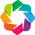

In [52]:
import pandas as pd
import numpy as np
import holoviews as hv
from holoviews import opts, dim
from bokeh.io import export_svgs
from bokeh.models import Plot


hv.extension('bokeh') # Ensure backend is loaded

In [61]:
ex868 = filtered_sc1.loc[filtered_sc1["focal"] == 868]


In [75]:
ex868 = ex868.loc[ex868["partner"] == 504]
ex868 = ex868.loc[ex868["class"] != "co-consumed"]

In [76]:
ex868

,focal,partner,reaction,class,flux


In [ ]:
aa_exchange_sc1 = filtered_sc1.copy()
aa_exchange_sc1 = aa_exchange_sc1[aa_exchange_sc1["reaction"].map(met_class_dict)== "Amino Acids/Peptides"]

aa_exchange_sc2 = filtered_sc2.copy()
aa_exchange_sc2 = aa_exchange_sc2[aa_exchange_sc2["reaction"].map(met_class_dict)== "Amino Acids/Peptides"]


In [ ]:
sugar_exchange_sc1 = filtered_sc1.copy()
sugar_exchange_sc1 = sugar_exchange_sc1[sugar_exchange_sc1["reaction"].map(met_class_dict)== "Sugars"]

sugar_exchange_sc2 = filtered_sc2.copy()
sugar_exchange_sc2 = sugar_exchange_sc2[sugar_exchange_sc2["reaction"].map(met_class_dict)== "Sugars"]

In [ ]:
vitamin_exchange_sc1 = filtered_sc1.copy()
vitamin_exchange_sc1 = vitamin_exchange_sc1[vitamin_exchange_sc1["reaction"].map(met_class_dict)== "Vitamins/Cofactors"]

vitamin_exchange_sc2 = filtered_sc2.copy()
vitamin_exchange_sc2 = vitamin_exchange_sc2[vitamin_exchange_sc2["reaction"].map(met_class_dict)== "Vitamins/Cofactors"]

In [418]:
 #==================== FOR HvSC1 ====================
# filtered_sc1 = inter_sc1[inter_sc1["metabolite"].apply(lambda x: x[:-2] not in mets2filter)]
#threshold_sc1 = filtered_sc1['flux'].quantile(0)
#strong_links_sc1 = filtered_sc1[filtered_sc1['flux'] >= threshold_sc1].copy()

sugar_exchange_sc1['source'] = sugar_exchange_sc1['focal'].astype(str).str.split("_").str[0]
sugar_exchange_sc1['target'] = sugar_exchange_sc1['partner'].astype(str).str.split("_").str[0]
sugar_exchange_sc1 = sugar_exchange_sc1.rename(columns={'flux': 'weight'})

aggregated_links_sc1 = sugar_exchange_sc1.groupby(['source', 'target'], as_index=False)['weight'].sum()
aggregated_links_sc1 = aggregated_links_sc1[aggregated_links_sc1['weight'] != 0.0]
# Calculate exchange degree
deg_source_sc1 = aggregated_links_sc1.groupby('source').size()
deg_target_sc1 = aggregated_links_sc1.groupby('target').size()
degree_df_sc1 = deg_source_sc1.add(deg_target_sc1, fill_value=0).astype(int).reset_index()
degree_df_sc1.columns = ['name', 'degree']

# Merge degree column into your nodes dataframe
nodes_sc1 = pd.DataFrame({'name': sorted(set(aggregated_links_sc1['source']).union(aggregated_links_sc1['target']))})
nodes_sc1 = nodes_sc1.merge(degree_df_sc1, on='name', how='left').fillna(0)

# Build Dataset and Chord (Notice 'labels' is NOT used here anymore)
nodes_ds_sc1 = hv.Dataset(nodes_sc1, kdims=['name'], vdims=['degree'])
chord_sc1 = hv.Chord((aggregated_links_sc1, nodes_ds_sc1), ['source', 'target'], ['weight'])

chord_sc1.opts(
    opts.Chord(
        cmap='Set2',
        edge_cmap='Set2',
        node_color=dim('name').str(),
        edge_color=dim('source').str(),
        width=600,                    
        height=600,               
        title="Sugar Exchange HvSC1 (Chord Diagram)",
        node_size=5+ dim('degree') * 0.75, 
        edge_alpha=0.85,
    )
)

nodes_sc1_df = chord_sc1.nodes.data.copy()
scale_sc1 = 1.175  # Adjust this value (e.g. 1.2) to push labels further out
nodes_sc1_df['x_scaled'] = nodes_sc1_df['x'] * scale_sc1
nodes_sc1_df['y_scaled'] = nodes_sc1_df['y'] * scale_sc1

# Create an independent Labels overlay
labels_sc1 = hv.Labels(nodes_sc1_df, kdims=['x_scaled', 'y_scaled'], vdims=['name'])
labels_sc1.opts(
    opts.Labels(
        text_font_size='10pt',
        text_align='center', 
        text_baseline='middle',
        text_color='black',
        angle = 0.5
    )
)

# Combine the plots
plot_sc1 = chord_sc1 * labels_sc1

plot = hv.renderer('bokeh').get_plot(plot_sc1).state
plot.output_backend='svg'
filepath = os.path.join(save_fig_dir, "Sugar_Exchanges_HvSC1.svg")


export_svgs(plot, filename=filepath)


['/home/emma/Dokumente/thesis/plotsnfigs/Sugar_Exchanges_HvSC1.svg']

In [419]:
plot_sc1

:Overlay
   .Chord.I  :Chord   [source,target]   (weight)
   .Labels.I :Labels   [x_scaled,y_scaled]   (name)

In [420]:
sugar_exchange_sc1

,focal,partner,reaction,class,weight,source,target
134,161,1334,EX_glyald_e,provided,0.256849,161,1334
1778,867,364,EX_g6p_B_e,received,0.265798,867,364
3759,1334,161,EX_glyald_e,received,0.256849,1334,161
4431,1334,1018,EX_glyald_e,received,3.589305,1334,1018
6901,364,867,EX_g6p_B_e,provided,0.265798,364,867
7424,364,644,EX_g6p_B_e,provided,0.385718,364,644
11532,504,644,EX_cellb_e,received,0.079462,504,644
15738,644,364,EX_g6p_B_e,received,0.385718,644,364
15895,644,504,EX_cellb_e,provided,0.079462,644,504
18617,1018,1334,EX_glyald_e,provided,3.589305,1018,1334


In [421]:
 #==================== FOR HvSC1 ====================
# filtered_sc1 = inter_sc1[inter_sc1["metabolite"].apply(lambda x: x[:-2] not in mets2filter)]
#threshold_sc1 = filtered_sc1['flux'].quantile(0)
#strong_links_sc1 = filtered_sc1[filtered_sc1['flux'] >= threshold_sc1].copy()

sugar_exchange_sc2['source'] = sugar_exchange_sc2['focal'].astype(str).str.split("_").str[0]
sugar_exchange_sc2['target'] = sugar_exchange_sc2['partner'].astype(str).str.split("_").str[0]
sugar_exchange_sc2 = sugar_exchange_sc2.rename(columns={'flux': 'weight'})

aggregated_links_sc2 = sugar_exchange_sc2.groupby(['source', 'target'], as_index=False)['weight'].sum()

# Calculate exchange degree
deg_source_sc2 = aggregated_links_sc2.groupby('source').size()
deg_target_sc2 = aggregated_links_sc2.groupby('target').size()
degree_df_sc2 = deg_source_sc2.add(deg_target_sc2, fill_value=0).astype(int).reset_index()
degree_df_sc2.columns = ['name', 'degree']

# Merge degree column into your nodes dataframe
nodes_sc2 = pd.DataFrame({'name': sorted(set(aggregated_links_sc2['source']).union(aggregated_links_sc2['target']))})
nodes_sc2 = nodes_sc2.merge(degree_df_sc2, on='name', how='left').fillna(0)

# Build Dataset and Chord (Notice 'labels' is NOT used here anymore)
nodes_ds_sc2 = hv.Dataset(nodes_sc2, kdims=['name'], vdims=['degree'])
chord_sc2 = hv.Chord((aggregated_links_sc2, nodes_ds_sc2), ['source', 'target'], ['weight'])

chord_sc2.opts(
    opts.Chord(
        cmap='Set2',
        edge_cmap='Set2',
        node_color=dim('name').str(),
        edge_color=dim('source').str(),
        width=600,                    
        height=600,               
        title="Sugar Exchange HvSC2 (Chord Diagram)",
        node_size=5+ dim('degree') * 0.75, 
        edge_alpha=0.85,
    )
)

# Extract calculated layout node positions & push them outward [ref: 3.2]
nodes_sc2_df = chord_sc2.nodes.data.copy()
scale_sc2 = 1.175  # Adjust this value (e.g. 1.2) to push labels further out
nodes_sc2_df['x_scaled'] = nodes_sc2_df['x'] * scale_sc2
nodes_sc2_df['y_scaled'] = nodes_sc2_df['y'] * scale_sc2    

# Create an independent Labels overlay
labels_sc2 = hv.Labels(nodes_sc2_df, kdims=['x_scaled', 'y_scaled'], vdims=['name'])
labels_sc2.opts(
    opts.Labels(
        text_font_size='10pt',
        text_align='center', 
        text_baseline='middle',
        text_color='black',
        angle = 0.5
    )
)

# Combine the plots
plot_sc2 = chord_sc2 * labels_sc2
plot = hv.renderer('bokeh').get_plot(plot_sc2).state
plot.output_backend='svg'
filepath = os.path.join(save_fig_dir, "Sugar_Exchanges_HvSC2.svg")

#export_svgs(plot, filename=filepath)

In [422]:
plot_sc2

:Overlay
   .Chord.I  :Chord   [source,target]   (weight)
   .Labels.I :Labels   [x_scaled,y_scaled]   (name)

In [423]:
fp = plot_sc1 + plot_sc2


In [424]:
fp

:Layout
   .Overlay.I  :Overlay
      .Chord.I  :Chord   [source,target]   (weight)
      .Labels.I :Labels   [x_scaled,y_scaled]   (name)
   .Overlay.II :Overlay
      .Chord.I  :Chord   [source,target]   (weight)
      .Labels.I :Labels   [x_scaled,y_scaled]   (name)

In [428]:
sugar_exchange_sc1["reaction"].unique()

array(['EX_glyald_e', 'EX_g6p_B_e', 'EX_cellb_e'], dtype=object)

In [287]:
fp = plot_sc1 + plot_sc2

bokeh_layout = hv.renderer('bokeh').get_plot(fp).state

for plot in bokeh_layout.select(dict(type=Plot)):
    plot.output_backend = 'svg'


filepath = os.path.join(save_fig_dir, "AA_Exchanges_Coms.svg")

export_svgs(bokeh_layout, filename=filepath)

['/home/emma/Dokumente/thesis/plotsnfigs/AA_Exchanges_Coms.svg',
 '/home/emma/Dokumente/thesis/plotsnfigs/AA_Exchanges_Coms_1.svg']

#### HEATMAP FOR EXCHANGES

In [101]:
# coconsumption 
df_clean1 = coconsumption_sc1.copy()
df_clean1['producer'] = df_clean1['focal'].astype(str).str.split("_").str[0]
df_clean1['consumer'] = df_clean1['partner'].astype(str).str.split("_").str[0]

# Group by strains and count unique metabolites exchanged [1.1, 1.2]
matrix_df1 = df_clean1.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_df1.rename(columns={'reaction': 'number_exchanges'}, inplace=True)


# --- Clean SC2 ---
df_clean2 = coconsumption_sc2.copy()
df_clean2['producer'] = df_clean2['focal'].astype(str).str.split("_").str[0]
df_clean2['consumer'] = df_clean2['partner'].astype(str).str.split("_").str[0]

# Group by strains and count unique metabolites exchanged [1.1, 1.2]
matrix_df2 = df_clean2.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_df2.rename(columns={'reaction': 'number_exchanges'}, inplace=True)

# --- Build Pivoted Heatmap Matrices --- [1.4]
heatmap_matrix1_cc = matrix_df1.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)
heatmap_matrix2_cc = matrix_df2.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)

In [102]:
# Find the overall min and max between both datasets
min_val = min(heatmap_matrix1_cc.values.min(), heatmap_matrix2_cc.values.min())
max_val = max(heatmap_matrix1_cc.values.max(), heatmap_matrix2_cc.values.max())

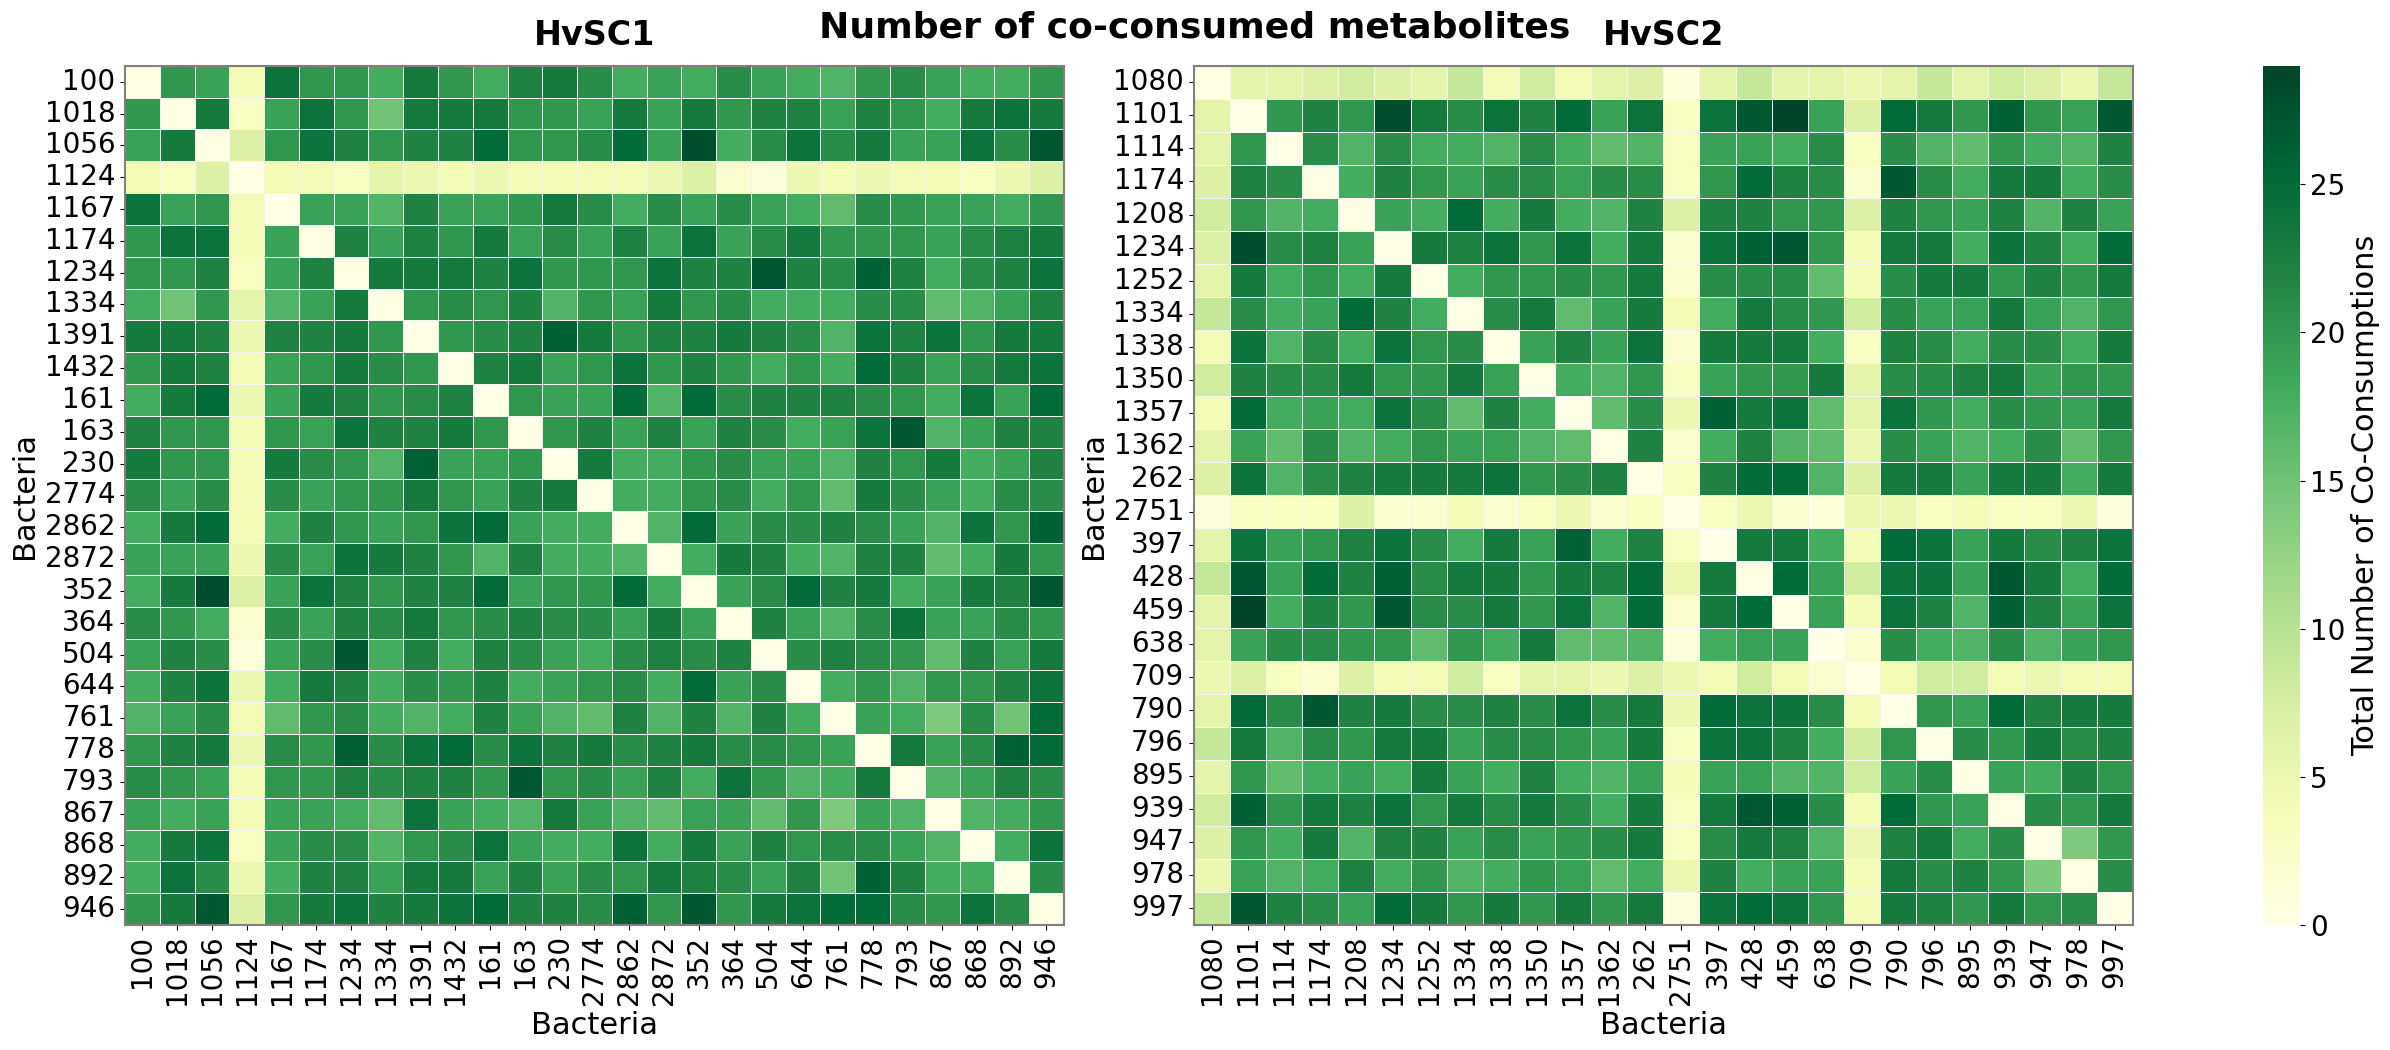

In [103]:
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, 
    figsize= (24, 11), 
    sharey=False,
    gridspec_kw={'width_ratios': [1, 1, 0.04]}
)
fig.suptitle("Number of co-consumed metabolites", fontsize=title_size, fontweight='bold', y=0.95)

sns.heatmap(
    heatmap_matrix1_cc, 
    ax=ax1,               
    cmap="YlGn", 
    robust=True,            
    vmin=min_val,               
    vmax=max_val,   
    cbar = False,             
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax1.set_title("HvSC1", fontsize=subtitle_size, fontweight='bold', pad=15)
ax1.tick_params(labelsize=tick_size, axis = "both")
ax1.set_xlabel("Bacteria", fontsize=axis_labels)
ax1.set_ylabel("Bacteria", fontsize=axis_labels)


for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

sns.heatmap(
    heatmap_matrix2_cc, 
    ax=ax2,                     
    cmap="YlGn", 
    cbar_ax= cbar_ax,        
    robust=True,            
    vmin=min_val,                
    vmax=max_val,               
    cbar_kws={'label': 'Total Number of Co-Consumptions'},
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax2.set_title("HvSC2", fontsize=subtitle_size, fontweight='bold', pad=15)
ax2.tick_params(labelsize=tick_size, axis = "both")
ax2.set_xlabel("Bacteria", fontsize=axis_labels)
ax2.set_ylabel("Bacteria", fontsize=axis_labels)

cbar = ax2.collections[0].colorbar
cbar.set_label('Total Number of Co-Consumptions', size=legend_size)
cbar.ax.tick_params(labelsize=tick_size)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

plt.tight_layout() 
fp = os.path.join(save_fig_dir+"Combined_Numbercoconsumptions_heatmap.svg")
plt.savefig(fp)
plt.show()

In [98]:
# --- Clean SC1 ---
df_clean1 = filtered_sc1.copy()
df_clean1['producer'] = df_clean1['focal'].astype(str).str.split("_").str[0]
df_clean1['consumer'] = df_clean1['partner'].astype(str).str.split("_").str[0]

# Group by strains and count unique metabolites exchanged [1.1, 1.2]
matrix_df1 = df_clean1.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_df1.rename(columns={'reaction': 'number_exchanges'}, inplace=True)


# --- Clean SC2 ---
df_clean2 = filtered_sc2.copy()
df_clean2['producer'] = df_clean2['focal'].astype(str).str.split("_").str[0]
df_clean2['consumer'] = df_clean2['partner'].astype(str).str.split("_").str[0]

# Group by strains and count unique metabolites exchanged [1.1, 1.2]
matrix_df2 = df_clean2.groupby(['producer', 'consumer'], as_index=False)['reaction'].nunique()
matrix_df2.rename(columns={'reaction': 'number_exchanges'}, inplace=True)


# --- Build Pivoted Heatmap Matrices --- [1.4]
heatmap_matrix1 = matrix_df1.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)
heatmap_matrix2 = matrix_df2.pivot(index='producer', columns='consumer', values='number_exchanges').fillna(0)

In [99]:
# Find the overall min and max between both datasets
min_val = min(heatmap_matrix1.values.min(), heatmap_matrix2.values.min())
max_val = max(heatmap_matrix1.values.max(), heatmap_matrix2.values.max())

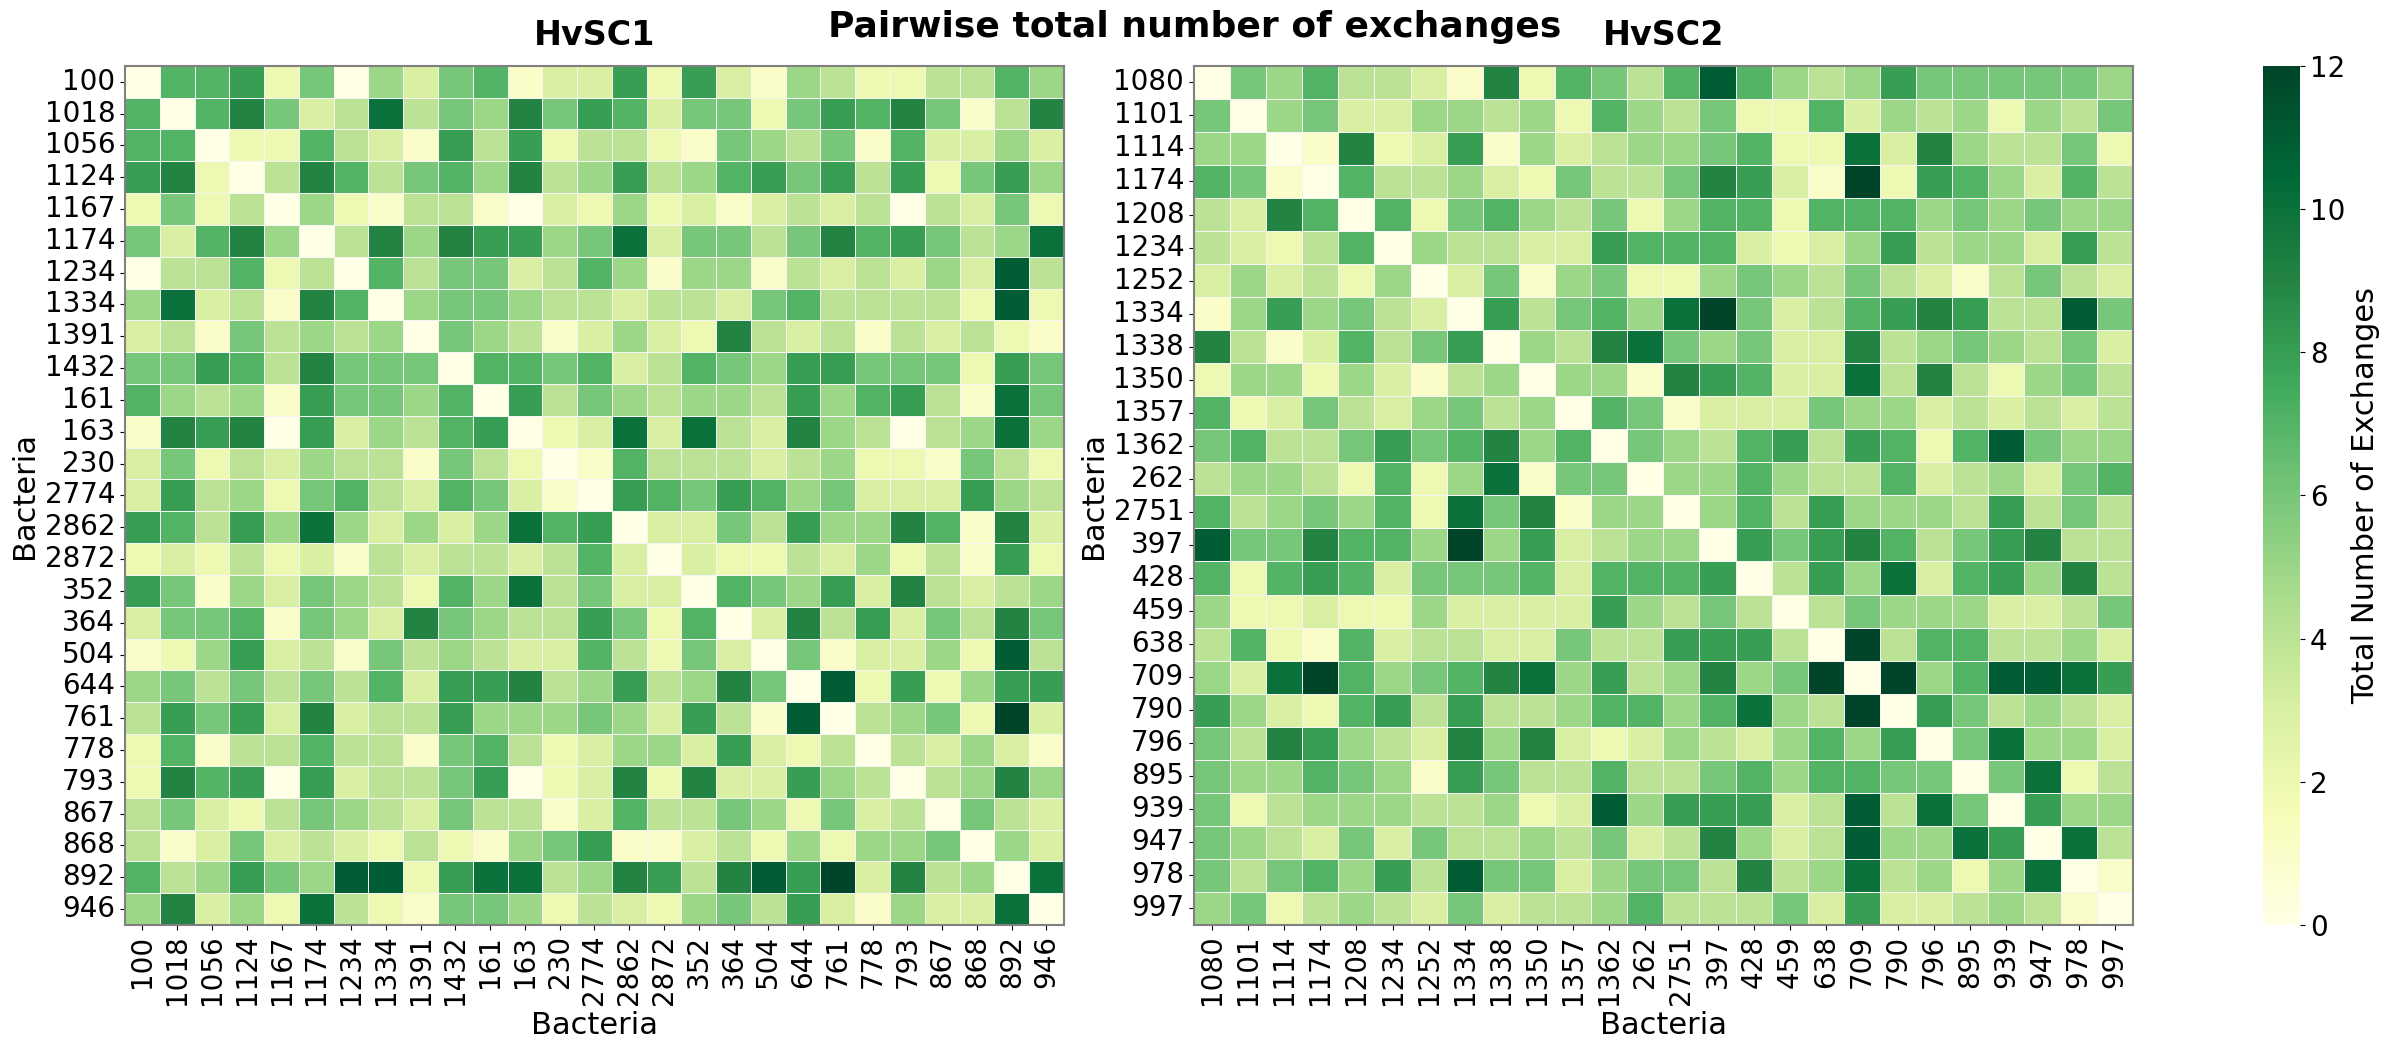

In [100]:
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, 
    figsize= (24, 11), 
    sharey=False,
    gridspec_kw={'width_ratios': [1, 1, 0.04]}
)
fig.suptitle("Pairwise total number of exchanges", fontsize=title_size, fontweight='bold', y=0.95)

sns.heatmap(
    heatmap_matrix1, 
    ax=ax1,               
    cmap="YlGn", 
    robust=True,            
    vmin=min_val,               
    vmax=max_val,   
    cbar = False,             
    #cbar_kws={'label': 'Total Number of Exchanges'},
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax1.set_title("HvSC1", fontsize=subtitle_size, fontweight='bold', pad=15)
ax1.tick_params(labelsize=tick_size, axis = "both")
ax1.set_xlabel("Bacteria", fontsize=axis_labels)
ax1.set_ylabel("Bacteria", fontsize=axis_labels)


for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

sns.heatmap(
    heatmap_matrix2, 
    ax=ax2,                     
    cmap="YlGn", 
    cbar_ax= cbar_ax,        
    robust=True,            
    vmin=min_val,                
    vmax=max_val,               
    cbar_kws={'label': 'Total Number of Exchanges'},
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax2.set_title("HvSC2", fontsize=subtitle_size, fontweight='bold', pad=15)
ax2.tick_params(labelsize=tick_size, axis = "both")
ax2.set_xlabel("Bacteria", fontsize=axis_labels)
ax2.set_ylabel("Bacteria", fontsize=axis_labels)

cbar = ax2.collections[0].colorbar
cbar.set_label('Total Number of Exchanges', size=legend_size)
cbar.ax.tick_params(labelsize=tick_size)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

plt.tight_layout() 
fp = os.path.join(save_fig_dir+"Combined_Numberexcg_heatmap.svg")
plt.savefig(fp)
plt.show()

In [432]:
filtered_sc1["class"].nunique()

3

In [81]:
import pandas as pd

# ==========================================
# COMMUNITY 1 (HvSC1)
# ==========================================
df_bal1 = filtered_sc1.copy()
df_bal1['producer'] = df_bal1['focal'].astype(str).str.split("_").str[0]
df_bal1['consumer'] = df_bal1['partner'].astype(str).str.split("_").str[0]

# Only keep 'provided' class
df_prov1 = df_bal1[df_bal1["class"] == "provided"].copy()

# 1. Base aggregations [ref: 1.2 (previous turn)]
pair_fluxes1 = df_prov1.groupby(['producer', 'consumer'], as_index=False)['flux'].sum()
pair_numberrxns1 = df_prov1.groupby(["producer", "consumer"], as_index=False)["reaction"].nunique()

# 2. FLUX MERGE: Explicitly rename columns of the right dataframe to prevent clashing [ref: 1.4]
right_fluxes1 = pair_fluxes1.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'flux': 'flux_provided_by_B'
})

trade_df1 = pd.merge(
    pair_fluxes1.rename(columns={'flux': 'flux_provided_by_A'}),
    right_fluxes1,
    on=['producer', 'consumer'],
    how='inner'  # Guarantees we only compare bidirectional interactions
)

trade_df1['balance'] = trade_df1['flux_provided_by_A'] - trade_df1['flux_provided_by_B']
heatmap_matrix1 = trade_df1.pivot(index='producer', columns='consumer', values='balance').fillna(0)


# 3. METABOLITE NUMBER MERGE: Same clean pattern [ref: 1.4]
right_nrxn1 = pair_numberrxns1.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'reaction': 'metabolite_provided_by_B'
})

trade_nrxn_df1 = pd.merge(
    pair_numberrxns1.rename(columns={'reaction': 'metabolite_provided_by_A'}),
    right_nrxn1,
    on=['producer', 'consumer'],
    how='inner'
)

trade_nrxn_df1['balance'] = trade_nrxn_df1['metabolite_provided_by_A'] - trade_nrxn_df1['metabolite_provided_by_B']
heatmap_matrix1rxn = trade_nrxn_df1.pivot(index='producer', columns='consumer', values='balance').fillna(0)


# ==========================================
# COMMUNITY 2 (HvSC2)
# ==========================================
df_bal2 = filtered_sc2.copy()
df_bal2['producer'] = df_bal2['focal'].astype(str).str.split("_").str[0]
df_bal2['consumer'] = df_bal2['partner'].astype(str).str.split("_").str[0]

df_prov2 = df_bal2[df_bal2["class"] == "provided"].copy()

# 1. Base aggregations
pair_fluxes2 = df_prov2.groupby(['producer', 'consumer'], as_index=False)['flux'].sum()
pair_numberrxns2 = df_prov2.groupby(["producer", "consumer"], as_index=False)["reaction"].nunique()

# 2. FLUX MERGE
right_fluxes2 = pair_fluxes2.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'flux': 'flux_provided_by_B'
})

trade_df2 = pd.merge(
    pair_fluxes2.rename(columns={'flux': 'flux_provided_by_A'}),
    right_fluxes2,
    on=['producer', 'consumer'],
    how='inner'
)

trade_df2['balance'] = trade_df2['flux_provided_by_A'] - trade_df2['flux_provided_by_B']
heatmap_matrix2 = trade_df2.pivot(index='producer', columns='consumer', values='balance').fillna(0)


# 3. METABOLITE NUMBER MERGE
right_nrxn2 = pair_numberrxns2.rename(columns={
    'producer': 'consumer', 
    'consumer': 'producer', 
    'reaction': 'metabolite_provided_by_B'
})

trade_nrxn_df2 = pd.merge(
    pair_numberrxns2.rename(columns={'reaction': 'metabolite_provided_by_A'}),
    right_nrxn2,
    on=['producer', 'consumer'],
    how='inner'
)

trade_nrxn_df2['balance'] = trade_nrxn_df2['metabolite_provided_by_A'] - trade_nrxn_df2['metabolite_provided_by_B']
heatmap_matrix2rxn = trade_nrxn_df2.pivot(index='producer', columns='consumer', values='balance').fillna(0)


# ==========================================
# SCALE LIMITS & RANGE
# ==========================================
min_val = min(heatmap_matrix1.values.min(), heatmap_matrix2.values.min())
max_val = max(heatmap_matrix1.values.max(), heatmap_matrix2.values.max())

min_valnrxn = min(heatmap_matrix1rxn.values.min(), heatmap_matrix2rxn.values.min())
max_valnrxn = max(heatmap_matrix1rxn.values.max(), heatmap_matrix2rxn.values.max())

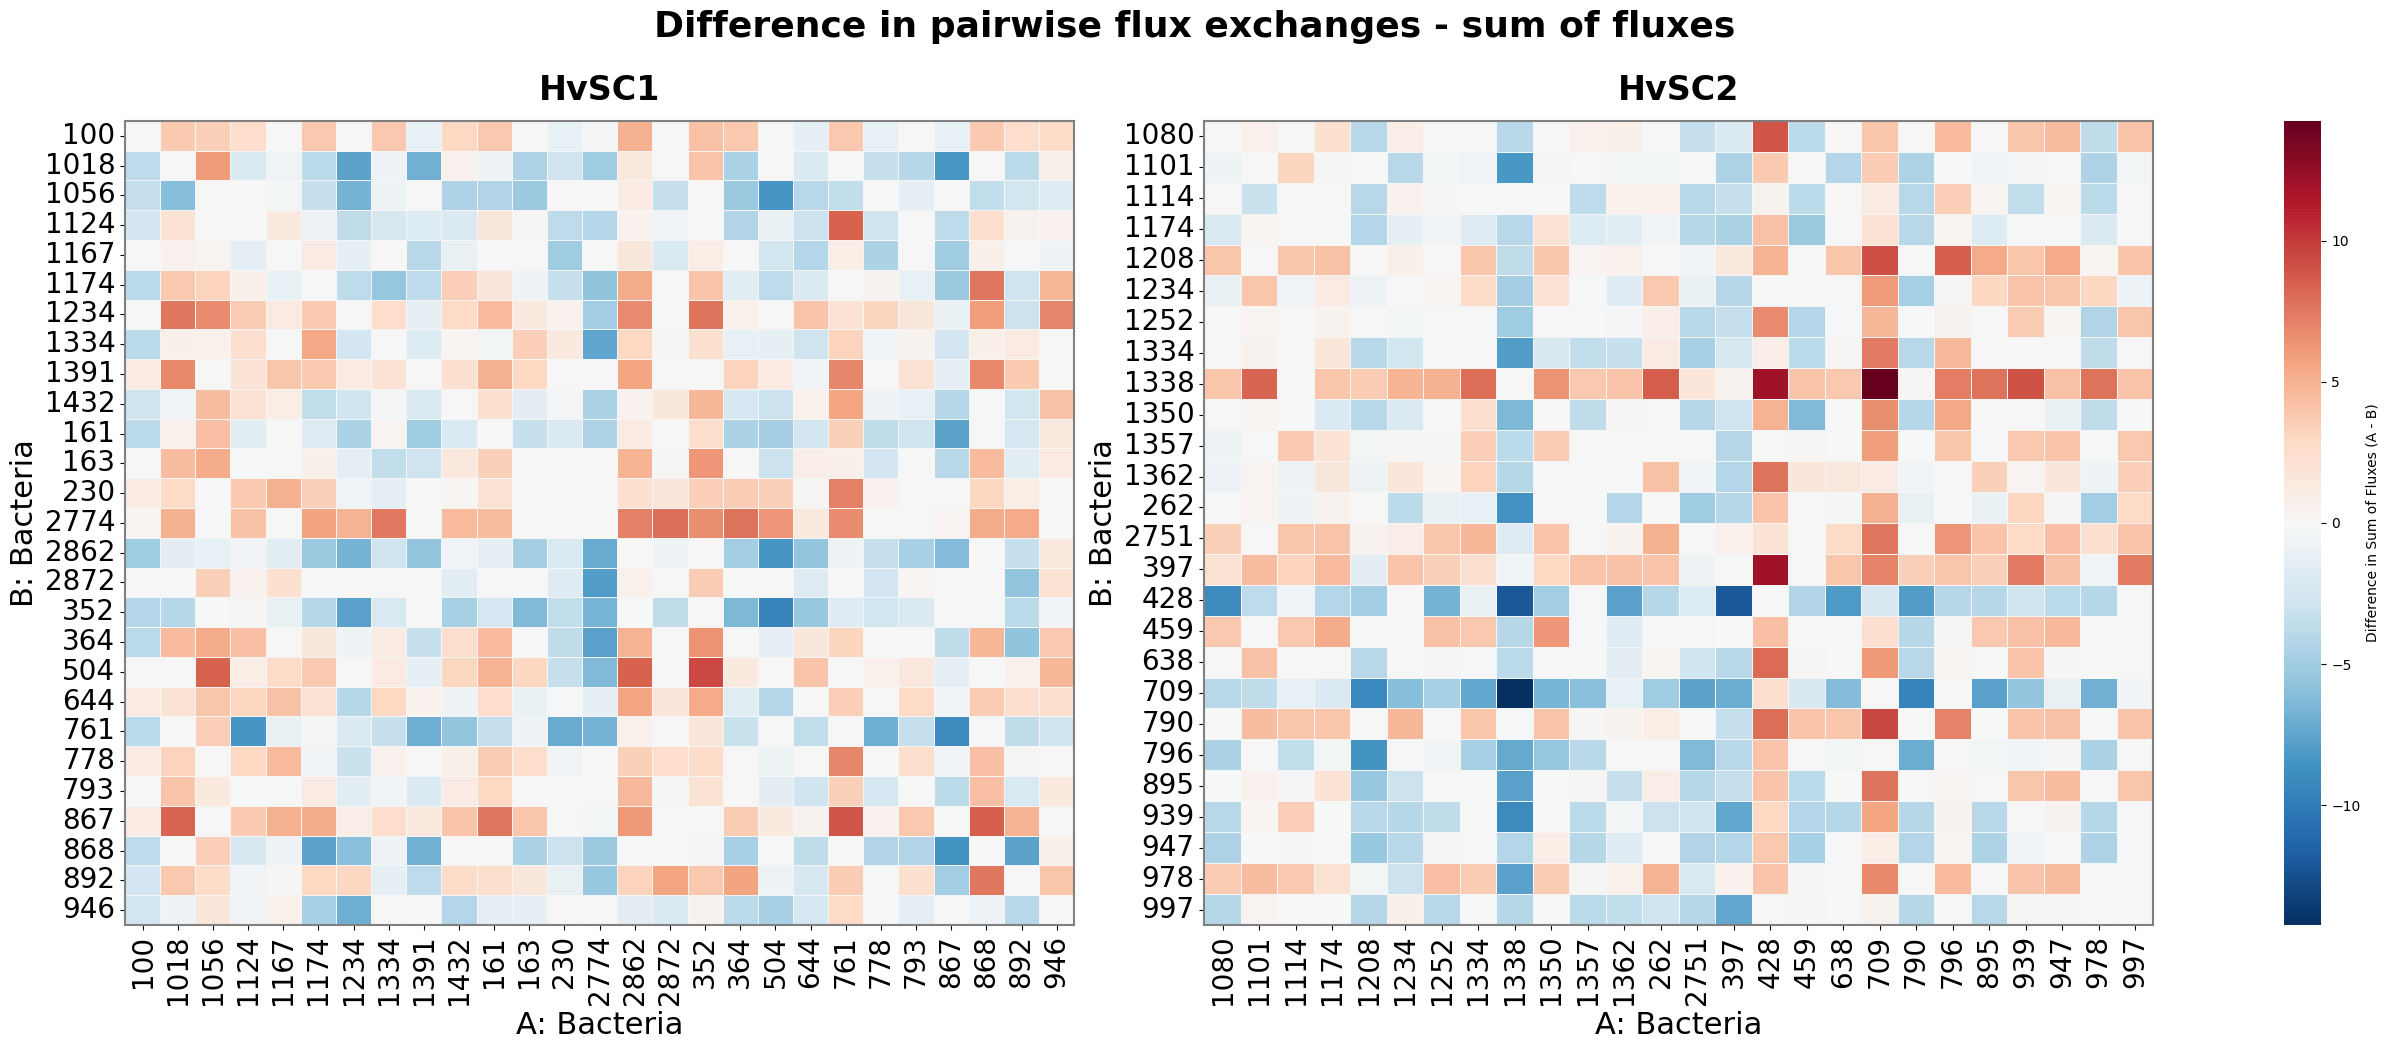

In [84]:
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, 
    figsize=(24, 11), 
    sharey=False,
    sharex= False,
    gridspec_kw={'width_ratios': [1, 1, 0.04]}  
)

fig.suptitle("Difference in pairwise flux exchanges - sum of fluxes", fontsize=title_size, fontweight='bold', y=0.95)

sns.heatmap(
    heatmap_matrix1, 
    ax=ax1,               
    cmap="RdBu_r",          
    robust=True,            
    vmin=min_val,               
    vmax=max_val,   
    cbar=False,             
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax1.set_title("HvSC1", fontsize=subtitle_size, fontweight='bold', pad=15)
ax1.tick_params(labelsize=tick_size, axis="both")
ax1.set_xlabel("A: Bacteria", fontsize=axis_labels)
ax1.set_ylabel("B: Bacteria", fontsize=axis_labels)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)


# 4. Plot HvSC2 Heatmap
sns.heatmap(
    heatmap_matrix2, 
    ax=ax2,                     
    cmap="RdBu_r", 
    cbar_ax=cbar_ax,        
    robust=True,            
    vmin=min_val,                
    vmax=max_val,               
    cbar_kws={'label': 'Difference in Sum of Fluxes (A - B)'},
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax2.set_title("HvSC2", fontsize=subtitle_size, fontweight='bold', pad=15)
ax2.tick_params(labelsize=tick_size, axis="both")
ax2.set_xlabel("A: Bacteria", fontsize=axis_labels)
ax2.set_ylabel("B: Bacteria", fontsize=axis_labels)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)


plt.tight_layout(rect=[0, 0, 1, 0.95]) 
fp = os.path.join(save_fig_dir, "Combined_sumflux_balance_heatmap.svg")
plt.savefig(fp, bbox_inches='tight')
plt.show()

#### micom visuals

In [ ]:
pl = plot_growth(grow_sc1, filename="growth_rates_sc1_tsbcomcomplete.html")

In [ ]:
pl = plot_growth(grow_sc2, filename="growth_rates_sc2_tsbcomcomplete.html")

In [ ]:

pl = plot_mes(grow_sc1,  filename="mes_sc1_tsbcomcomplete.html")

In [ ]:
pl = plot_mes(grow_sc2,  filename="mes_sc2_tsbcomcomplete.html")

In [ ]:
mes_sc1_s = pd.read_csv("/home/emma/Dokumente/thesis/communities/mse_sc1_tsbcomcomplete.csv")
mes_sc2_s = pd.read_csv("/home/emma/Dokumente/thesis/communities/mse_sc2_tsbcomcomplete.csv")

In [ ]:
mes_sc1_s["syncom"] = "sc1"
mes_sc2_s["syncom"] = "sc2"
combined_mes = pd.concat([mes_sc1_s, mes_sc2_s], ignore_index=True)

In [ ]:
combined_mes["met_class"] = combined_mes["reaction"].map(met_class_dict)

In [ ]:
class_mes = combined_mes.dropna(subset=["met_class"]).copy()

class_averages = (
    class_mes.groupby(["met_class", "syncom"])["MES"]
    .mean()
    .reset_index()
)

num_classes = class_averages["met_class"].nunique()

fig, ax = plt.subplots(figsize=(10, max(5, num_classes * 0.5)))

sns.pointplot(
    data=class_averages,
    x="MES",
    y="met_class",
    hue="syncom",
    join=False,          
    dodge=0.3,           
    palette="Set1",
    markers="o",
    scale=1.2,
    ax=ax
)

# Add horizontal divider lines between the classes
for i in range(num_classes - 1):
    ax.axhline(y=i + 0.5, color="gray", linestyle="-", alpha=0.2, linewidth=1)

ax.set_title("Average MES by Metabolite Class", fontsize=14, pad=15)
ax.set_xlabel("MES Score", fontsize=12)
ax.set_ylabel("Metabolite Class", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.5, axis="x")

ax.legend(title="SynCom", bbox_to_anchor=(0.5, -0.35), ncol = 2, loc='lower center')

plt.tight_layout()
plt.show()

#### compare indivudual growth rates

In [15]:
gr_sc1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_pfba_10_individualtaxon_growth.csv")
gr_sc2 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_pfba_10_individualtaxon_growth.csv")
#gr_sc1["compartment"] = gr_sc1["taxon"].str.split("_").str[0]
#gr_sc2["taxon"] = gr_sc2["taxon"].str.split("_").str[0]

In [49]:
gr_sc2 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC2_l2pfba_10_individualtaxon_growth.csv")
gr_sc1 = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_l2pfba_10_individualtaxon_growth.csv")

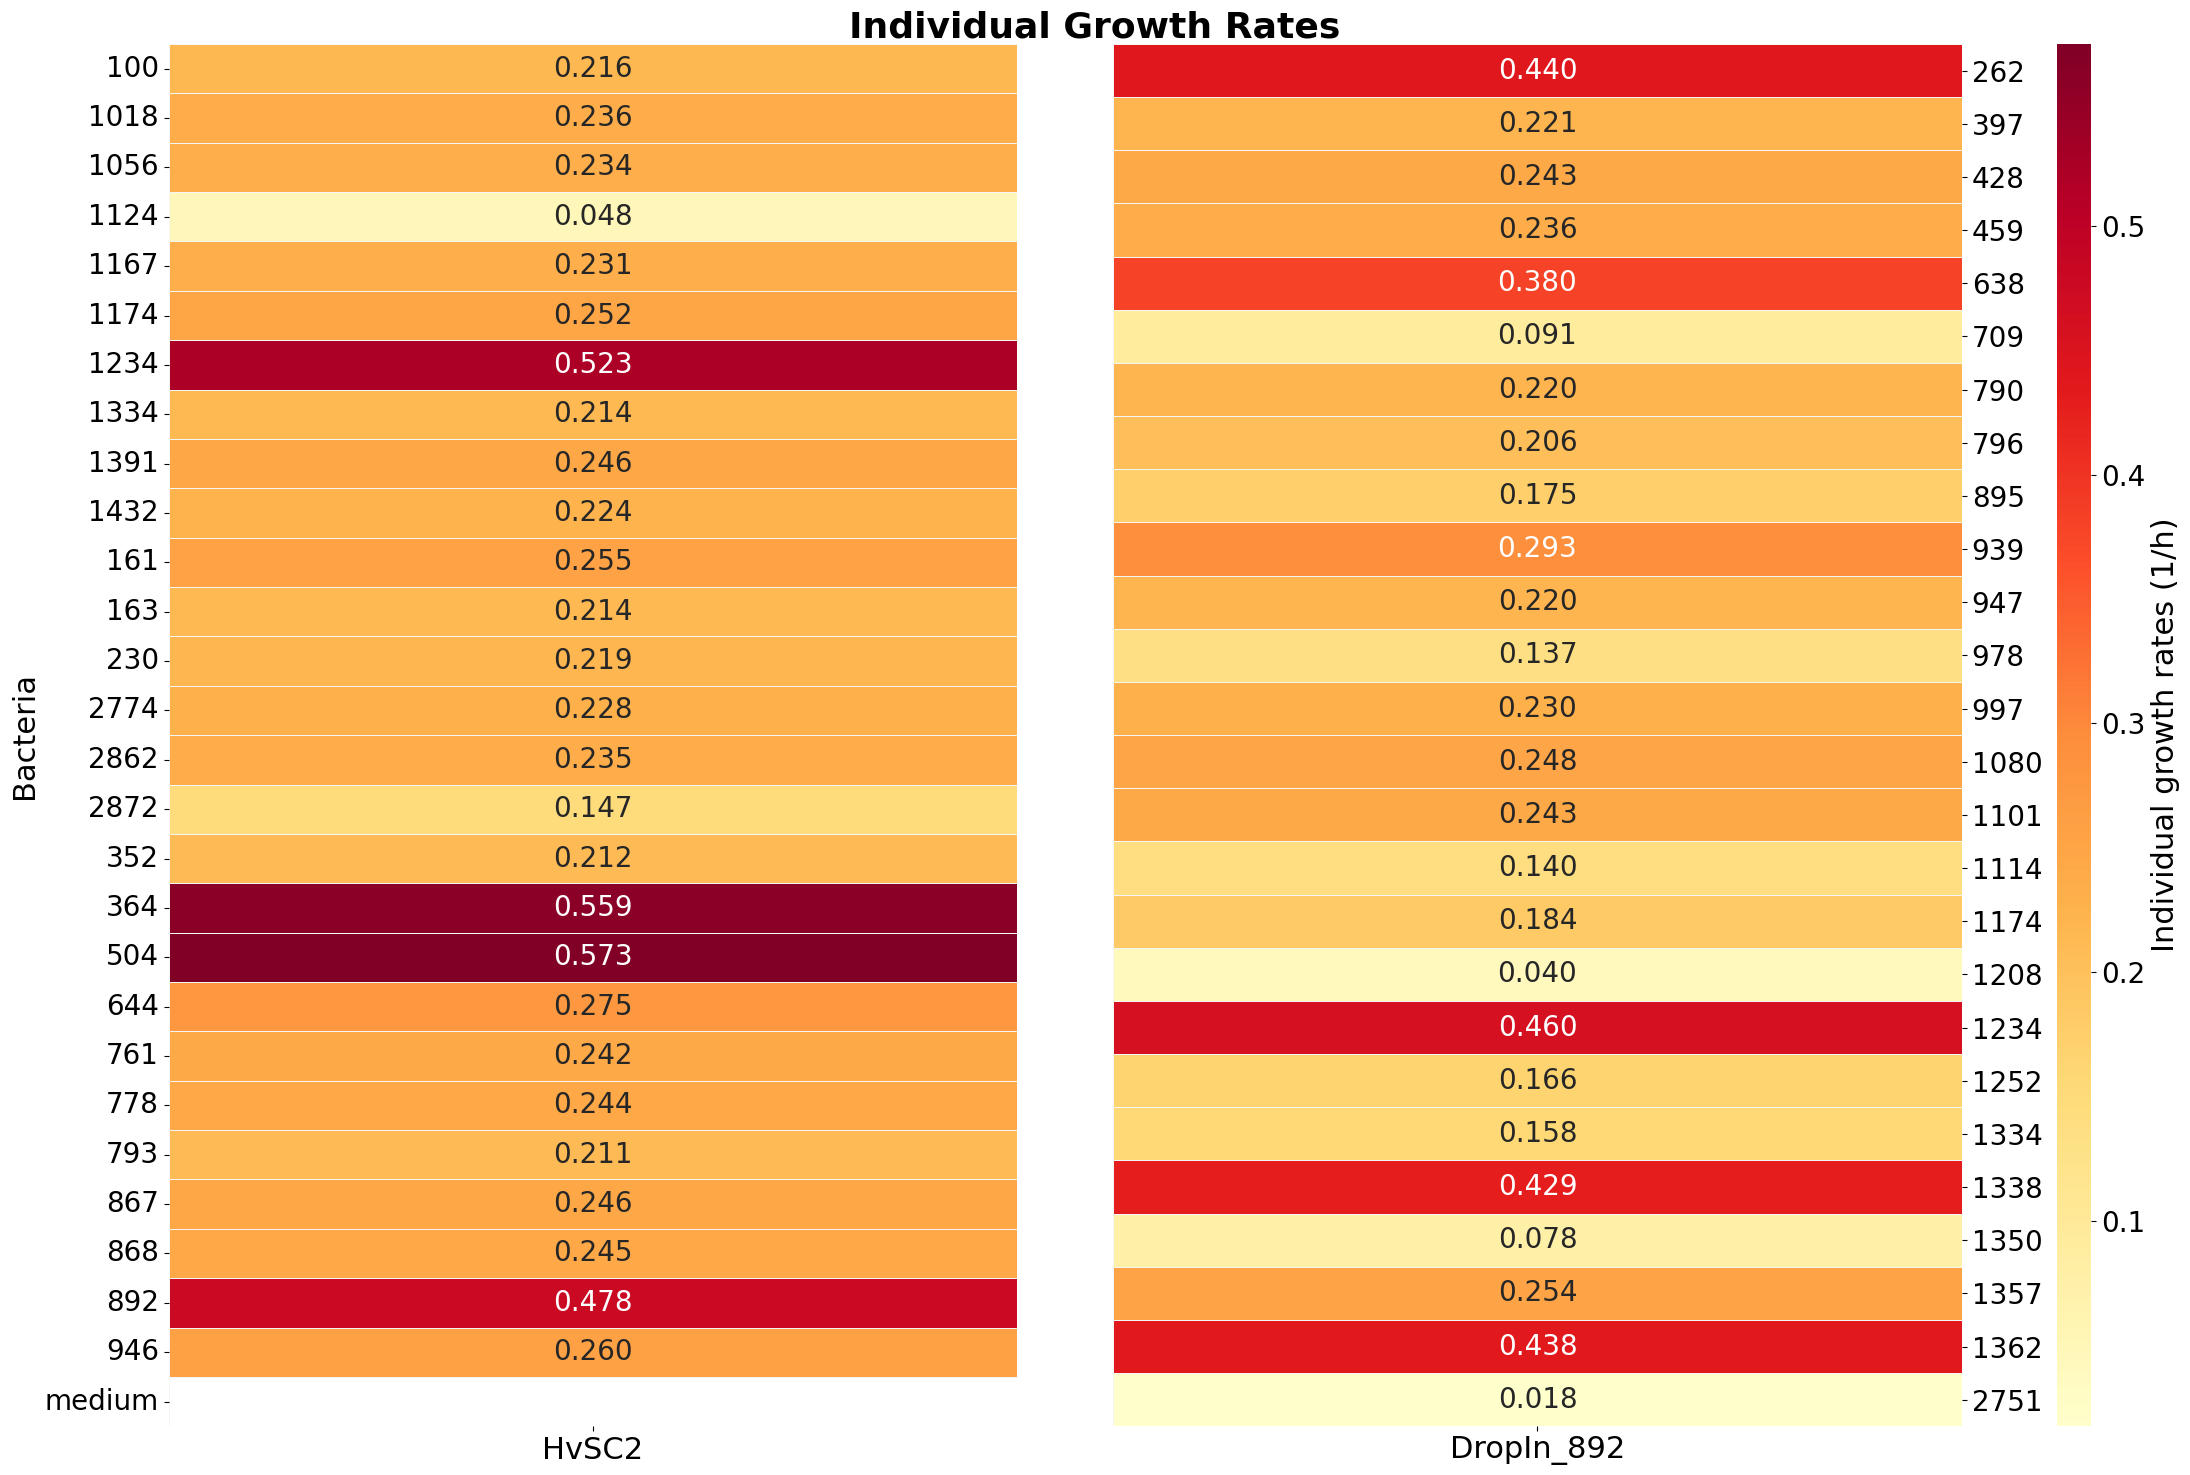

In [50]:
gr_sc1 = gr_sc1.set_index("compartments")
gr_sc2 = gr_sc2.set_index("compartments")

#gr_sc2.index = gr_sc2.index.astype(int)
idx1 = set(gr_sc1.index)
idx2 = set(gr_sc2.index)

shared_species = sorted(list(idx1 & idx2))
unique_to_sc1 = sorted(list(idx1 - idx2))
unique_to_sc2 = sorted(list(idx2 - idx1))

sc1_ordered_idx = shared_species + unique_to_sc1
sc2_ordered_idx = shared_species + unique_to_sc2

sc1_gr_clean = gr_sc1.loc[sc1_ordered_idx]
sc2_gr_clean = gr_sc2.loc[sc2_ordered_idx]

sc1_gr_clean["com"] = "HvSC2"
sc2_gr_clean["com"] = "DropIn_892"

sc1_gr_clean["growth_rate"] = sc1_gr_clean["growth_rate"] * (1/len(sc1_gr_clean["growth_rate"]))
sc2_gr_clean["growth_rate"] = sc2_gr_clean["growth_rate"] * (1/len(sc2_gr_clean["growth_rate"]))


sc1_pivoted = sc1_gr_clean.pivot(columns="com", values="growth_rate").reindex(sc1_ordered_idx)
sc2_pivoted = sc2_gr_clean.pivot(columns="com", values="growth_rate").reindex(sc2_ordered_idx)

# 3. Calculate common scale limits
min_gr = min(sc1_gr_clean['growth_rate'].min(), sc2_gr_clean['growth_rate'].min())
max_gr = max(sc1_gr_clean['growth_rate'].max(), sc2_gr_clean['growth_rate'].max())

# 4. Set up the figure layout
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, 
    figsize=(22, 15), 
    sharey=False,
    sharex=False,
    gridspec_kw={'width_ratios': [1, 1, 0.04]}  
)
annot_size = 20


fig.suptitle("Individual Growth Rates", fontsize=title_size, fontweight='bold', y=0.98)

sns.heatmap(
    sc1_pivoted,     
    ax=ax1,               
    cmap="YlOrRd",   
    robust=True,  
    vmin=min_gr,
    vmax=max_gr,
    annot=True,  
    fmt=".3f",
    cbar=False, 
    annot_kws={'size': annot_size},              
    linewidths=0.5,         
    linecolor='whitesmoke'
)
ax1.set_ylabel("Bacteria", fontsize=axis_labels)
ax1.set_xlabel("")
ax1.tick_params(labelsize=tick_size, labelrotation = 0, axis="y")
ax1.tick_params(labelsize=legend_size, axis="x")

for spine in ax1.spines.values():
   # spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)
sns.heatmap(
    sc2_pivoted,     
    ax=ax2,               
    cmap="YlOrRd",   
    robust=True,  
    vmin=min_gr,
    vmax=max_gr,
    annot=True,  
    annot_kws={'size': annot_size},                   
    fmt=".3f",
    linewidths=0.5,  
    cbar=True,
    cbar_ax=cbar_ax,       
    linecolor='whitesmoke',
    cbar_kws={'label': 'Individual growth rates (1/h)'},

)

cbar = ax2.collections[0].colorbar
cbar.set_label('Individual growth rates (1/h)', size=legend_size) 
cbar.ax.tick_params(labelsize=tick_size)

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.tick_params(labelsize=tick_size, labelrotation = 0,  axis="y")
ax2.tick_params(labelsize=legend_size, axis="x")

for spine in ax2.spines.values():
   # spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

# 5. Render
plt.tight_layout()
fp = os.path.join(save_fig_dir, "Individual_growthrates_heatmap_l2pfba.svg")
plt.savefig(fp, bbox_inches='tight')

plt.show()

### analyse niche overlap 

##### co-consumption 

In [41]:
cc_sc1 = filtered_sc1[filtered_sc1["class"] == "co-consumed"]
cc_sc2 = filtered_sc2[filtered_sc2["class"] == "co-consumed"]

In [186]:
total_cc_flux_sc1 = cc_sc1["flux"].sum()
total_cc_flux_sc2 = cc_sc2["flux"].sum()

print(f"HvSC1 co-consumption flux: {total_cc_flux_sc1}\nHvSC2 co-consumption flux: {total_cc_flux_sc2}")

HvSC1 co-consumption flux: 1862.6543578929059
HvSC2 co-consumption flux: 1668.5036276754693


In [42]:
cc_sc1['strainA'] = cc_sc1['focal'].astype(str).str.split("_").str[0]
cc_sc1['strainB'] = cc_sc1['partner'].astype(str).str.split("_").str[0]
matrix_df1 = cc_sc1.groupby(['strainA', 'strainB'], as_index=False)['metabolite'].nunique()
matrix_df1.rename(columns={'metabolite': 'number_coconsumption'}, inplace=True)

heatmap_matrix1 = matrix_df1.pivot(index='strainA', columns='strainB',values='number_coconsumption').fillna(0)

cc_sc2['strainA'] = cc_sc2['focal'].astype(str).str.split("_").str[0]
cc_sc2['strainB'] = cc_sc2['partner'].astype(str).str.split("_").str[0]
matrix_df2 = cc_sc2.groupby(['strainA', 'strainB'], as_index=False)['metabolite'].nunique()
matrix_df2.rename(columns={'metabolite': 'number_coconsumption'}, inplace=True)

heatmap_matrix2 = matrix_df2.pivot(index='strainA', columns='strainB',values='number_coconsumption').fillna(0)


/tmp/ipykernel_15592/3436966808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cc_sc1['strainA'] = cc_sc1['focal'].astype(str).str.split("_").str[0]
/tmp/ipykernel_15592/3436966808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cc_sc1['strainB'] = cc_sc1['partner'].astype(str).str.split("_").str[0]
/tmp/ipykernel_15592/3436966808.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [224]:
# Find the overall min and max between both datasets
min_val = min(heatmap_matrix1.values.min(), heatmap_matrix2.values.min())
max_val = max(heatmap_matrix1.values.max(), heatmap_matrix2.values.max())

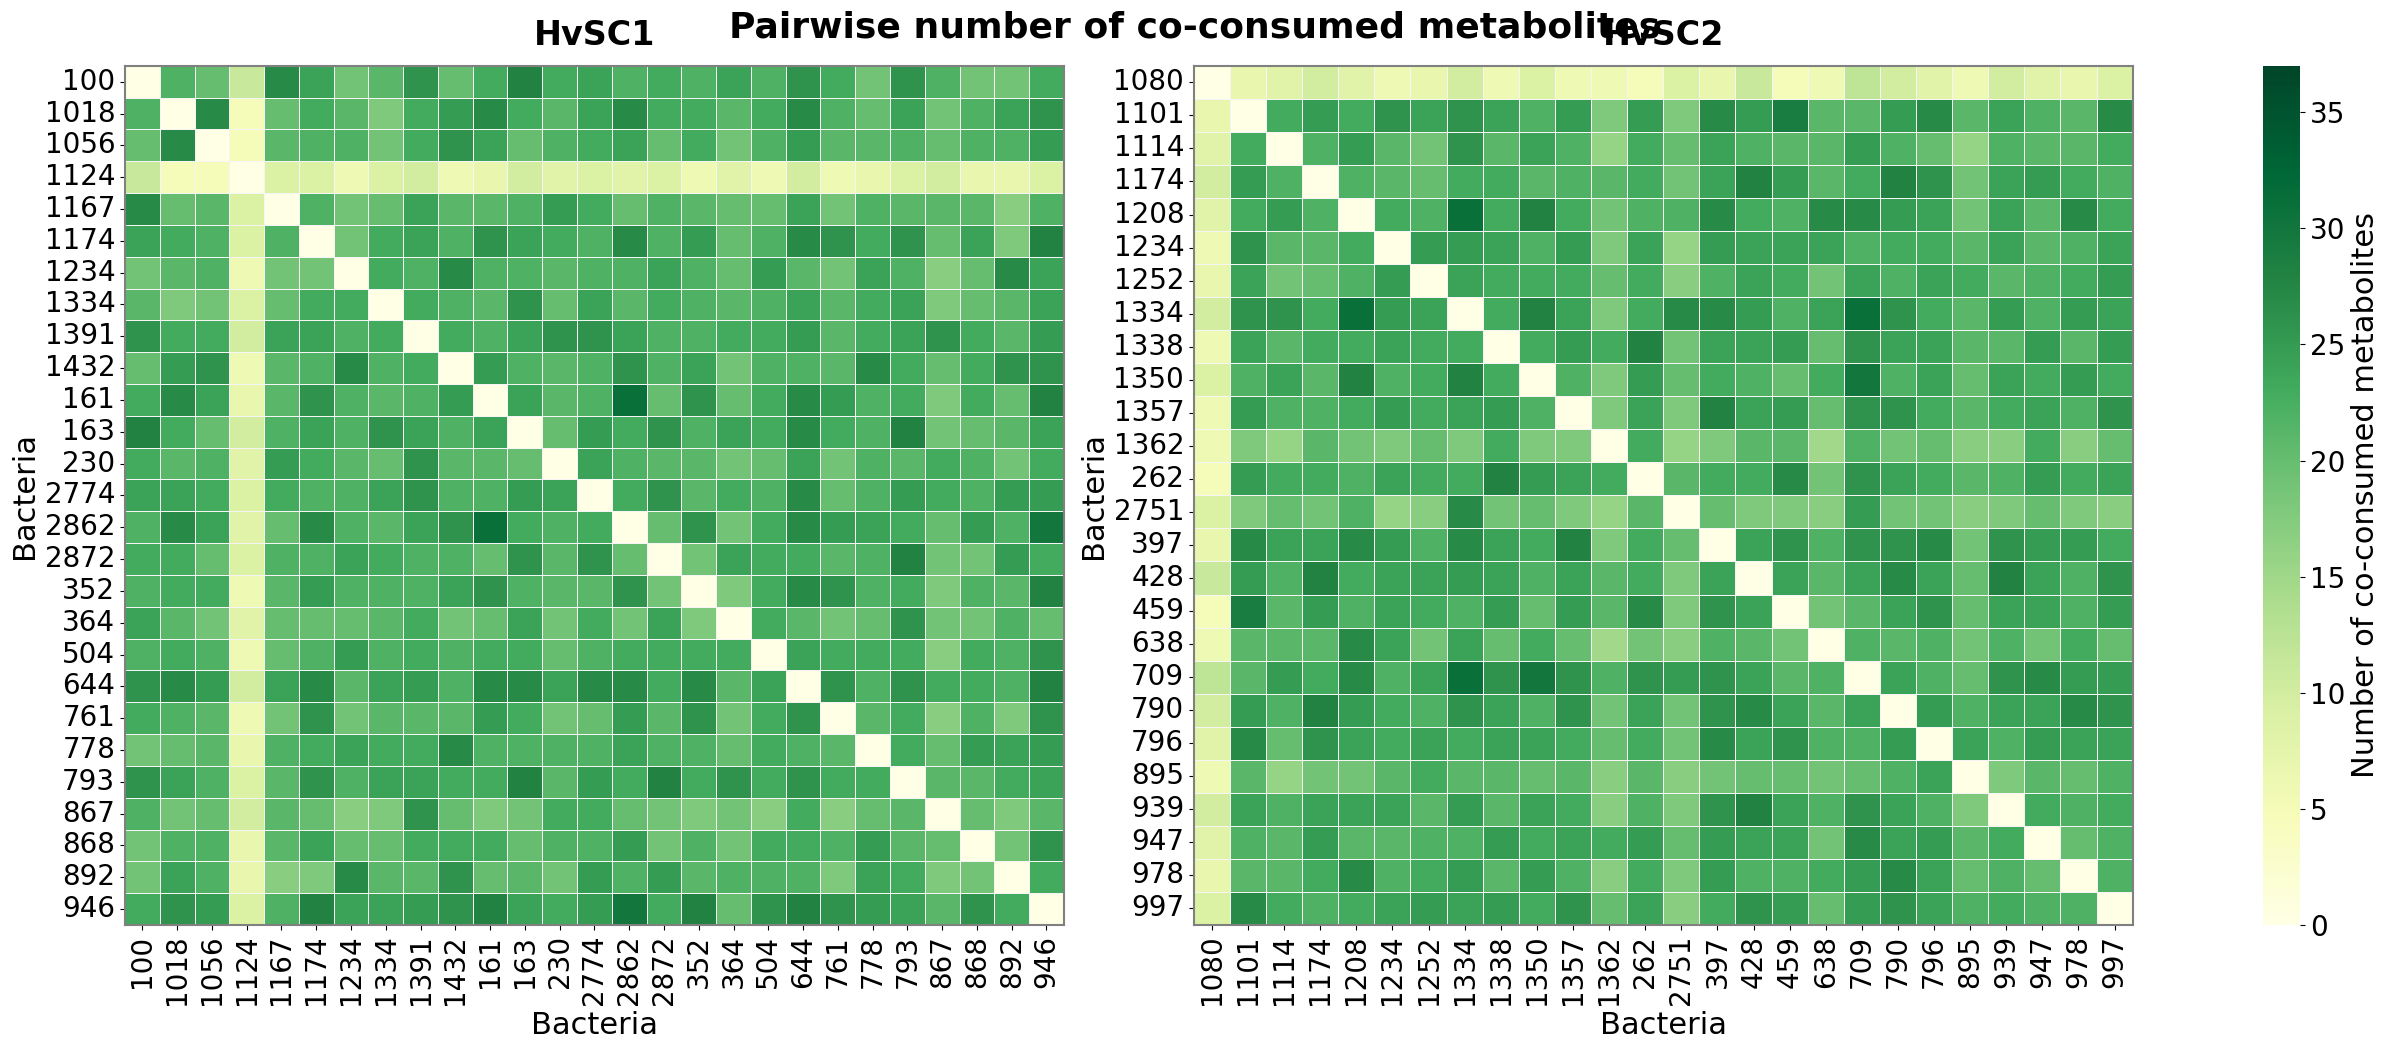

In [43]:
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, 
    figsize= (24, 11), 
    sharey=False,
    gridspec_kw={'width_ratios': [1, 1, 0.04]}
)
fig.suptitle("Pairwise number of co-consumed metabolites", fontsize=title_size, fontweight='bold', y=0.95)

sns.heatmap(
    heatmap_matrix1, 
    ax=ax1,               
    cmap="YlGn", 
    robust=True,            
    vmin=min_val,               
    vmax=max_val,   
    cbar = False,             
    #cbar_kws={'label': 'Total Number of Exchanges'},
    linewidths=0.5,         
    linecolor='whitesmoke'
)

ax1.set_title("HvSC1", fontsize=subtitle_size, fontweight='bold', pad=15)
ax1.tick_params(labelsize=tick_size, axis = "both")
ax1.set_xlabel("Bacteria", fontsize=axis_labels)
ax1.set_ylabel("Bacteria", fontsize=axis_labels)


for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

sns.heatmap(
    heatmap_matrix2, 
    ax=ax2,                     
    cmap="YlGn", 
    cbar_ax= cbar_ax,        
    robust=True,            
    vmin=min_val,                
    vmax=max_val,               
    cbar_kws={'label': 'Total Number of Exchanges'},
    linewidths=0.5,         
    linecolor='whitesmoke'
)
cbar = ax2.collections[0].colorbar
cbar.set_label('Number of co-consumed metabolites', size=legend_size)
cbar.ax.tick_params(labelsize=tick_size)

ax2.set_title("HvSC2", fontsize=subtitle_size, fontweight='bold', pad=15)
ax2.tick_params(labelsize=tick_size, axis = "both")
ax2.set_xlabel("Bacteria", fontsize=axis_labels)
ax2.set_ylabel("Bacteria", fontsize=axis_labels)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('grey')
    spine.set_linewidth(1.5)

plt.tight_layout() 
fp = os.path.join(save_fig_dir+"Combined_Number_coconsumption_heatmap.svg")
plt.savefig(fp)
plt.show()

##### metabolic resource competition

# Part II &mdash; Load Models & Compare Growth Across Media

## 1. Setup

### 1.1 Imports

In [11]:

import os
import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')

import pandas as pd
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import seaborn as sns
import cobra
from collections import defaultdict
import numpy as np
from copy import deepcopy
#from upsetplot import UpSet, from_indicators, from_contents
from venn import venn
import math
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted, venn3
from functions import *
from micom import load_pickle
from micom.media import complete_medium, minimal_medium


### 1.2 Paths & reference files

In [12]:
media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/add_exr/"
media_save_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"

In [12]:
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

In [13]:
met_class_df = pd.read_csv(met_class)
met_class_dict = dict(zip(met_class_df["Reaction"], met_class_df["Category"]))

In [14]:
viridis_cmap = plt.colormaps['viridis']
magma_cmap = plt.colormaps['magma']

### 1.3 Load all predefined media (raw CSVs)

In [17]:
# Load and store all media 
AF7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_AF_mock.csv"))
AF8 = pd.read_csv(os.path.join(media_dir, "media_barley - 8dpi_AF_mock.csv"))
Root7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_Root_media_liquidphase.csv"))
Root8 = pd.read_csv(os.path.join(media_dir, "media_barley - 8dpi_Root_media_liquidphase.csv"))
TSB = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/TSB_medium.csv", header=None)

### 1.4 Helper function

In [18]:
def compute_medium_series(csv_medium):
    new_id = csv_medium.copy()
    new_id[0] = new_id[0].astype(str).str.strip().str.replace(r'\d+$', '', regex=True)
    new_id[0] = new_id[0].str.replace('_e', '_m')
    flux_values = pd.to_numeric(new_id[1], errors='coerce').fillna(1000.0)
    med_series = pd.Series(flux_values.values, index=new_id[0].astype(str).str.strip())
    med_series = med_series[med_series.index.notna() & (med_series.index != 'nan')]
    return med_series

## 2. Create Media Objects & Compare Single-Model Growth Across Media

In [19]:
# create_medium() turns each raw media CSV into a {exchange_reaction: flux} dict usable directly as model.medium.
AF7 = create_medium(AF7)
AF8 = create_medium(AF8)
Root7 = create_medium(Root7)
Root8 = create_medium(Root8)
TSB = create_medium(TSB)

In [20]:
mediadict = {"AF7" : AF7, "AF8": AF8, "Root7": Root7, "Root8": Root8, "TSB": TSB}

In [ ]:
# For every curated strain model, run FBA on its complete medium and on every predefined medium in mediadict.
compare_growth_media = {}

for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    
    default_medium = model.medium.copy()
    
    cur_m = []
    
    sol_base = model.slim_optimize()
    cur_m.append(("Complete_Medium", sol_base))
    
    for med_name, cur_med in mediadict.items():
        try:
            medium_ = get_model_specific_medium(model, cur_med)
            model.medium = medium_
            
            sol = model.slim_optimize()
            cur_m.append((med_name, sol))
            
        except Exception as e:
            print(f"Error simulating {med_name} on model {model_id}: {e}")
            cur_m.append((med_name, 0.0)) 
            
        finally:
            model.medium = default_medium
            
    compare_growth_media[model_id] = cur_m

In [ ]:
df_growthrate2medium = pd.DataFrame({
    model_id: dict(results) for model_id, results in compare_growth_media.items()
}).T

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_growthrate2medium, 
    annot=True,              # Write the numeric growth rates inside the cells
    cmap='viridis',          # Clear color gradient (dark = no growth, yellow = fast growth)
    fmt=".2f",               # Format values to 2 decimal places
    linewidths=0.5,          # Subtle line grid separating cells
    cbar_kws={'label': 'Predicted Growth Rate ($h^{-1}$)'}, 
    ax=ax
)

ax.set_title('Predicted Growth Rates Across Models and Media Formulations', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Simulated Media Conditions', fontsize=12, labelpad=10)
ax.set_ylabel('Metabolic Models', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. COBRA Minimal Medium per Model & Gaps vs. Predefined Media

Uses `cobra.medium.minimal_medium` (single-model level) as opposed to the community-level `micom` minimal/complete medium functions used in Part I.

In [ ]:
minimal_medium = {}
min_med_growth_rates = {}
for file in os.listdir(model_dir):
    if not file.endswith(('.xml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    #print(model_id)
    mini_med = cobra.medium.minimal_medium(model, 1.0, exports = True, minimize_components=True)
    minimal_medium[model_id] = mini_med

    if mini_med is not None:
        default_medium = model.medium.copy()
        try:
            model.medium = mini_med.to_dict() 
            growth_rate = model.slim_optimize()
            min_med_growth_rates[model_id] = growth_rate if not np.isnan(growth_rate) else 0.0
        except Exception as e:
            print(f"Error calculating growth on minimal medium for {model_id}: {e}")
            min_med_growth_rates[model_id] = 0.0
        finally:
            model.medium = default_medium  
    else:
        # If no minimal medium was found, growth rate is 0.0
        min_med_growth_rates[model_id] = 0.0

In [ ]:
# Count, across all models, how many models require each exchange reaction in their minimal medium.
# list of all EX_reactions from minimal_media
count_mods_per_reaction = defaultdict(list)

for model_id, medium in minimal_medium.items():
    if medium is None:
        print(f"Skipping {model_id} because no minimal medium could be found.")
        continue
    for ex_r, flux in medium.items():
        if flux > 0:
            count_mods_per_reaction[ex_r].append(model_id)

In [ ]:
# For every exchange reaction required by at least one model, list which predefined media lack it.
# figure out which ex_r are missing in the predefined media
ex_r_missinginmedia = defaultdict(list)
for ex_r, counts in count_mods_per_reaction.items():
    if len(counts) >=1:
        for media_id, medium in mediadict.items():
            if ex_r not in medium.keys():
                ex_r_missinginmedia[ex_r].append(media_id)

In [ ]:
# Find all reactions missing from the all media
reactions_missing_in_all_media = [
    ex_r for ex_r, media_list in ex_r_missinginmedia.items() if len(media_list) == 5
]

print(f"Reactions missing in all media and at least 5 models: {reactions_missing_in_all_media}")
print(f"Count: {len(reactions_missing_in_all_media)}")

In [ ]:
missing_TSB = [reac_id for reac_id, media_ids in ex_r_missinginmedia.items() if "TSB" in media_ids]

## 4. Gap-Fill Predefined Media With Minimal-Medium Results

In [ ]:
# Add every reaction missing from TSB (as found above) into a copy of each predefined medium.
completed_media = {}
for medium_id, reactions in mediadict.items():
    medium_id_new = f"{medium_id}_completed"
    completed_media[medium_id_new] = deepcopy(reactions)

for ex_r in missing_TSB:
    #for medium_id in medium_ids:
    medium_id_new = medium_id + "_completed"
    completed_media[medium_id_new][ex_r] = 10.0


### 4.1 Bring in the community-level completed TSB medium (from Part I) for comparison

In [ ]:
TSB_completed_micom_e = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/Completed_TSB.csv")

In [ ]:
TSB_completed_micom_e = create_medium(TSB_completed_micom_e)

In [ ]:
# Community-level exchange IDs use the _m suffix; convert back to the single-model _e suffix for comparison.
TSB_completed_micom = {
    key.replace("_m", "_e"): value for key, value in TSB_completed_micom_e.items()
}


In [ ]:
# media of interest 
target_media = { }
target_media["TSB_community_complete"] = TSB_completed_micom
target_media["TSB_minimed"] = completed_media["TSB_completed"]

### 4.2 Re-run the growth comparison on the gap-filled / completed media

In [ ]:
compare_growth_media_complete = {}

for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    
    default_medium = model.medium.copy()
    
    cur_m = []
    
    sol_base = model.slim_optimize()
    cur_m.append(("Complete_Medium", sol_base))
    
    for med_name, cur_med in target_media.items():
        try:
            medium_ = get_model_specific_medium(model, cur_med)
            
            # --- FIX 1: Sanitize the incoming medium dictionary ---
            # Remove any keys that have nan values before applying to the model
            clean_medium = {
                rxn_id: val for rxn_id, val in medium_.items() 
                if not (isinstance(val, float) and math.isnan(val))
            }
            
            model.medium = clean_medium
            print(model.medium)
            sol = model.slim_optimize()
            if math.isnan(sol):
                sol = 0.0
                
            cur_m.append((med_name, sol))
            
        except Exception as e:
            print(f"Error simulating {med_name} on model {model_id}: {e}")
            cur_m.append((med_name, 0.0)) 
            
        finally:
            # --- FIX 2: Safeguard the reset ---
            # Reset to default medium
            model.medium = default_medium
            
    compare_growth_media_complete[model_id] = cur_m

In [ ]:
df_growthrate2medium_complete = pd.DataFrame({
    model_id: dict(results) for model_id, results in compare_growth_media_complete.items()
}).T

df_filtered = df_growthrate2medium_complete[(df_growthrate2medium_complete > 0).any(axis=1)]

dropped_count = len(df_growthrate2medium) - len(df_filtered)
if dropped_count > 0:
    print(f"Removed {dropped_count} model(s) with zero growth across all conditions.")

In [ ]:
df_growthrate_TSB = pd.concat([
    df_growthrate2medium["Complete_Medium"].rename("Complete Medium"),
    df_growthrate2medium["TSB"].rename("TSB"), 
    df_growthrate2medium_complete["TSB_completed"].rename("TSB Complete"), 
    
], axis=1)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_filtered,
    #df_filtered.iloc[:,[0, 5]],
    annot=True,              # Write the numeric growth rates inside the cells
    cmap='viridis',          # Clear color gradient (dark = no growth, yellow = fast growth)
    fmt=".2f",               # Format values to 2 decimal places
    linewidths=0.5,          # Subtle line grid separating cells
    cbar_kws={'label': 'Predicted Growth Rate ($h^{-1}$)'}, 
    ax=ax
)

ax.set_title('Predicted Growth Rates Across Models and Media Formulations', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Simulated Media Conditions', fontsize=12, labelpad=10)
ax.set_ylabel('Metabolic Models', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# sve TSB complete medium 
save_media(completed_media["TSB_completed"], "TSB_completed")

## 5. Compare Media Composition (Shared / Unique Components)

In [ ]:
all_media_comps = defaultdict(list)

for media_id, medium in mediadict.items():
    for ex_r in medium.keys():
        all_media_comps[ex_r].append(media_id)

### 5.1 What do the media share?

In [ ]:
medium = {"AF7": set(AF7.keys()), "AF8": set(AF8.keys()), "Root7" : set(Root7.keys()), "Root8" : set(Root8.keys())}
venn(medium)

In [ ]:
data = from_contents(medium)
upset = UpSet(data, show_counts=True, sort_by='cardinality')
axes = upset.plot()

# Y-axis of main plot
axes['intersections'].set_ylabel("Shared components")

# X-axis of totals
axes['totals'].set_xlabel("Amount medium components")


## 6. Metabolite-Class Composition of Media

In [ ]:
as_d, count_d = assign_metaboliteclass_medium(AF7, met_class_dict)

In [ ]:
all_media_counts = {}

for med_id, medium in mediadict.items():
    as_d, c_d = assign_metaboliteclass_medium(medium, met_class_dict)
    all_media_counts[med_id] = c_d


df_counts = pd.DataFrame(all_media_counts).fillna(0)
df_counts = df_counts.sort_index()
ax = df_counts.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title("Comparison of Metabolite Classes Across Media Profiles", fontsize=14, pad=15)
plt.xlabel("Metabolite Class", fontsize=12)
plt.ylabel("Count of Components", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Media Profiles")

plt.tight_layout()
plt.show()

## 7. Community Minimal-Medium "Playground" & Comparisons

In [ ]:
c1 = load_pickle("/home/emma/Dokumente/thesis/communities/HvSC1.pickle")
c2 = load_pickle("/home/emma/Dokumente/thesis/communities/HvSC2.pickle")

In [315]:
min_com_growth = 3
min_indi_growth = min_com_growth/27

In [299]:
AF7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_AF_mock.csv"), header = None)
AF7_s = compute_medium_series(AF7)

In [300]:
len(HvSC1_af7_2)

49

In [316]:
HvSC1_af7_2 = complete_medium(HvSC1, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)


[07/13/26 16:56:35] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=816137;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=473030;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [317]:
HvSC2_af7_2 = complete_medium(HvSC2, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)

[07/13/26 16:57:23] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=157460;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=876248;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [318]:
# Merge af_c1 and af_c2: if a reaction appears in both, keep the higher flux bound.
combined_afmedium_3 = HvSC1_af7_2.copy()
for ex_r, flux in HvSC2_af7_2.items():
    if ex_r not in combined_afmedium_3.keys():
        combined_afmedium_3[ex_r] = flux
    if ex_r in combined_afmedium_3.keys():
        if combined_afmedium_3[ex_r] < flux:
            combined_afmedium_3[ex_r] = flux

In [319]:
len(combined_afmedium_3)

53

In [320]:
combined_afmedium_3 = combined_afmedium_3.to_dict()

In [321]:
#combined_afmedium = combined_afmedium.to_dict()
save_media(combined_afmedium_3, "combined_af7_c3i327", media_save_dir)

,0
EX_4abut_m,10.000000
EX_acmana_m,0.001167
EX_acon_C_m,0.100000
EX_ala__L_m,10.000000
EX_asn__L_m,0.737814
EX_asp__L_m,10.000000
EX_ca2_m,1000.000000
EX_cit_m,10.000000
EX_cl_m,1000.000000
EX_cobalt2_m,1000.000000


In [291]:
HvSC1.medium = combined_afmedium_3

In [293]:
a = HvSC1.optimize()

In [295]:
b = HvSC2.optimize()

In [ ]:
min_med_sc1 = minimal_medium(HvSC1, 0.1, minimize_components = True)

[07/06/26 13:41:22] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=82138;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=985991;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [ ]:
min_med_sc2 = minimal_medium(HvSC2, 0.1, minimize_components = True)

[07/06/26 13:50:52] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=594081;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=522895;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [119]:
min_med_sc1_l = set(min_med_sc1.index)
min_med_sc2_l = set(min_med_sc2.index)

In [46]:
af7_l = set(AF7_s.index)

In [47]:
# TSB exchange IDs converted from the raw _e suffix to community-style _m naming.
tsb_m = []
for reac in TSB[0]:
    clean = reac[:-2]
    clean_m = clean + "_m"
    tsb_m.append(clean_m)

In [ ]:
intersect_sc1 = min_med_sc1_l.intersection(tsb_m)
only_af7_1 = af7_l - min_med_sc1_l
only_min1 = min_med_sc1_l - af7_l

In [ ]:
venn2(subsets=(len(af7_l), len(min_med_sc1_l), len(intersect_sc1)), set_labels=('AF7 base', 'MiniMed SC1'))

In [90]:
intersect = set(HvSC1_af7_1.keys()).intersection(set(HvSC2_af7_1.keys()))
only_sc1 = set(HvSC1_af7_1.keys()) - set(HvSC2_af7_1.keys())
only_sc2 = set(HvSC2_af7.keys()) - set(HvSC1_af7.keys())

In [91]:
only_sc2

set()

In [322]:
d1 = set(AF7_s.index) - set(HvSC1_af7_2.keys())
d2 = set(AF7_s.index) - set(HvSC2_af7_2.keys())

In [323]:
len(d1)

15

In [324]:
d43_1 = set(AF7_s.index) - d1
d43_2 = set(AF7_s.index) - d2

In [325]:
ex1 = set(HvSC1_af7_2.keys()) - d43_1
ex2 = set(HvSC2_af7_2.keys()) - d43_2

In [326]:
len(HvSC2_af7_2)

48

In [327]:
ex1, ex2

({'EX_R_3httdca_m',
  'EX_acmana_m',
  'EX_asn__L_m',
  'EX_rnam_m',
  'EX_tyr__L_m',
  'EX_uacgam_m'},
 {'EX_asn__L_m', 'EX_cu_m', 'EX_gly_asn__L_m', 'EX_glygln_m', 'EX_ribflv_m'})

In [288]:
helper_d = {"AF_sc1" : set(HvSC1_af7_2.keys()), "AF_sc2": set(HvSC2_af7_2.keys())}

In [289]:
from venn import venn

Text(0.5, 1.0, 'Overlap between AF7 and TSB')

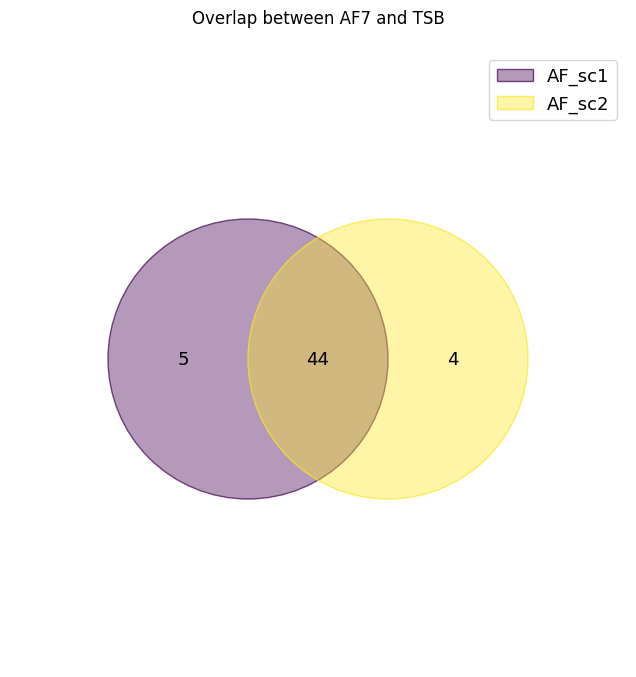

In [290]:
venn(helper_d)
plt.title("Overlap between AF7 and TSB", pad=20)

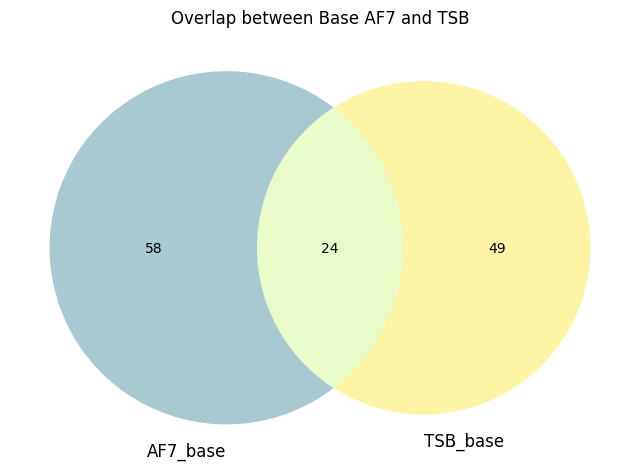

In [54]:
color_af7 = viridis_cmap(0.4)
color_tsb = viridis_cmap(0.99) 

plt.figure(figsize=(8, 6))

venn2(
    subsets=(len(af7_l), len(tsb_m), len(set(tsb_m).intersection(af7_l))), 
    set_labels=('AF7_base', 'TSB_base'), 
    set_colors=(color_af7, color_tsb)
)

plt.title("Overlap between Base AF7 and TSB")
plt.savefig(os.path.join(save_fig_dir, "Venn_AF7_TSB_base"))
plt.show()

In [ ]:
venn3(subsets=(len(af7_l), len(min_med_sc2_l), len(intersect_sc2), len(min_med_sc1_l), len(intersect_sc1), len(min_med_sc1_l.intersection(min_med_sc2_l)), len(set(intersect_sc1).intersection(intersect_sc2))), set_labels=('AF7_base', "MiniMed_SC1", 'MiniMed_SC2'))

In [ ]:
venn3(subsets=(len(af7_l), len(min_med_sc2_l), len(intersect_sc2), len(min_med_sc1_l), len(intersect_sc1), len(min_med_sc1_l.intersection(min_med_sc2_l)), len(set(intersect_sc1).intersection(intersect_sc2))), set_labels=('TSB', "MiniMed_SC1", 'MiniMed_SC2'))

### 7.1 What does each strain need individually?

In [ ]:
# Recomputes the per-model minimal media from Section 3 (duplicated here in the original notebook).
minimal_medium = {}
min_med_growth_rates = {}
for file in os.listdir(model_dir):
    if not file.endswith(('.xml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    #print(model_id)
    mini_med = cobra.medium.minimal_medium(model, 1.0, exports = True, minimize_components=True)
    minimal_medium[model_id] = mini_med

    if mini_med is not None:
        default_medium = model.medium.copy()
        try:
            model.medium = mini_med.to_dict() 
            growth_rate = model.slim_optimize()
            min_med_growth_rates[model_id] = growth_rate if not np.isnan(growth_rate) else 0.0
        except Exception as e:
            print(f"Error calculating growth on minimal medium for {model_id}: {e}")
            min_med_growth_rates[model_id] = 0.0
        finally:
            model.medium = default_medium  
    else:
        # If no minimal medium was found, growth rate is 0.0
        min_med_growth_rates[model_id] = 0.0

        
# list of all EX_reactions from minimal_media
count_mods_per_reaction = defaultdict(list)

for model_id, medium in minimal_medium.items():
    if medium is None:
        print(f"Skipping {model_id} because no minimal medium could be found.")
        continue
    for ex_r, flux in medium.items():
        if flux > 0:
            count_mods_per_reaction[ex_r].append(model_id)


In [ ]:
# figure out which ex_r are missing in the predefined media
onlyin2 = list()
ex_r_missinginmedia = defaultdict(list)
for ex_r, counts in count_mods_per_reaction.items():
    if len(counts) < 2:
        onlyin2.append(ex_r)

## 8. Per-Strain Essential Exchange Reactions (FVA-Based, HvSC1 Exploratory)
This part is not important, it just shows, that cobrapy is not able to work well with communities. Further this was a (failed) attempt of defining my own minimal media based on FVA.

In [ ]:
from cobra.flux_analysis import flux_variability_analysis

In [ ]:
min_growth = 0.1


In [ ]:
c1_x = read_sbml_model("/home/emma/Dokumente/thesis/communities/HvSC1.xml")
c2_x = read_sbml_model("/home/emma/Dokumente/thesis/communities/HvSC2.xml")

In [ ]:
# Set the community biomass ('Growth') reactions as objective and collect all exchange reactions.
c1_exr = []
biomass_c1 = {}
for reac in c1_x.reactions:
    if "Growth" in reac.id:
        biomass_c1[reac] = 1.0
        reac.bounds = (1/27, 1000)
    if "EX" in reac.id:
        c1_exr.append(reac)

In [ ]:
c1_x.objective = biomass_c1

In [ ]:
c1_x.slim_optimize()

In [ ]:
c1_fva = flux_variability_analysis(c1_x, c1_exr)

In [ ]:
# Summarize FVA ranges per underlying exchange reaction (community IDs are strain-suffixed, e.g. '__m_1174').
rows = {}
for ex_r in c1_fva.index:
    current_min = c1_fva.loc[ex_r, 'minimum']
    current_max = c1_fva.loc[ex_r, 'maximum']
    
    # Split from the right side at the double underscore exactly once
    # "EX_LalaDgluMdap_e__m_1174" becomes ["EX_LalaDgluMdap_e", "m_1174"]
    clean_id = ex_r.rsplit("__", 1)[0]
    
    if clean_id not in rows:
        rows[clean_id] = [current_min, current_max]
    else:
        if current_min < rows[clean_id][0]:
            rows[clean_id][0] = current_min
        if current_max > rows[clean_id][1]:
            rows[clean_id][1] = current_max

rows = [[id_key, values[0], values[1]] for id_key, values in rows.items()]
sum_fva_c1 = pd.DataFrame(rows, columns=["exchange_reaction", "min_value", "max_value"])
sum_fva_c1 = sum_fva_c1[sum_fva_c1["max_value"] < 0]

In [ ]:
c1_essential = cobra.flux_analysis.variability.find_essential_reactions(c1_x, threshold=0.1, processes=2)

In [ ]:
c1_essential_ids = {rxn.id if hasattr(rxn, 'id') else rxn for rxn in c1_essential}
c1_essential_exr  = [rxn for rxn in c1_essential_ids if "EX" in rxn]

In [ ]:
c1_essential_exr_sum = []
for ex_r in c1_essential_exr:    
    split_id = ex_r.split("_")
    clean_id = split_id[0] + "_" + split_id[1] + "_" + split_id[2]
    if clean_id not in c1_essential_exr_sum:
        c1_essential_exr_sum.append(clean_id)

In [ ]:
# Keep only essential import reactions (community-style _m ids, not _e).
c1_essential_imports = []

for ex_r in c1_essential_exr_sum:
    if ex_r in sum_fva_c1["exchange_reaction"].values:
        if "_m" in ex_r and "_e" not in ex_r:
            c1_essential_imports.append(ex_r)

In [ ]:
venn2(subsets = (len(c1_essential_imports), len(min_med_sc1_l), len(set(c1_essential_imports).intersection(min_med_sc1_l))), set_labels = ('essential EX', 'MiniMed_SC1'), set_colors=)

In [ ]:
# Try growing HvSC1 on nothing but its essential imports.
# reasign essential imports as medium and see how the stuff grows 
essential_imports_medium = {ex_r: 1000 for ex_r in c1_essential_imports}
medium_ = get_model_specific_medium(c1_x, essential_imports_medium)
c1_x.medium = medium_

In [ ]:
len(c1_x.medium)

In [ ]:
c1_x.optimize()

In [ ]:
set(c1_essential_imports).intersection(min_med_sc1_l)

In [ ]:
min_med_sc1_l - set(c1_essential_imports)

In [ ]:
true_minimal_med = cobra.medium.minimal_medium(c1_x, minimize_components=True)

functional_medium_dict = true_minimal_med.to_dict()
c1_x.medium = functional_medium_dict
solution = c1_x.optimize()
print( solution.objective_value)

## 9. Complete AF7 Medium for Both Communities (Model-Level View)

In [19]:
from micom import Community

In [20]:
taxonomy_df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

### 9.1 Define communities

In [70]:
HvSC1_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC1") | (taxonomy_df["Syncom"] == "Both")]
HvSC1_df = HvSC1_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC1_df["id"] = HvSC1_df["id"].astype(str)
HvSC1_df["abundance"] = 1
HvSC1_df["file"] = HvSC1_df['id'].apply(lambda x: f"{model_dir}/{x}_ex.xml")

In [71]:
HvSC1 = Community(HvSC1_df, id = "HvSC1", name = "HvSC1")

Output()

In [72]:
HvSC2_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df = HvSC2_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df["id"] = HvSC2_df["id"].astype(str)
HvSC2_df["abundance"] = 1
HvSC2_df["file"] = HvSC2_df['id'].apply(lambda x: f"{model_dir}/{x}_ex.xml")

In [73]:
HvSC2 = Community(HvSC2_df, id = "HvSC2", name = "HvSC2")

Output()

### 9.2 Complete AF7 medium per community & compare to minimal medium

In [21]:
min_com_growth = 0.1
min_indi_growth = 0.01

In [22]:
AF7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_AF_mock.csv"), header = None)
AF7_s = compute_medium_series(AF7)

In [23]:
af_c1 = complete_medium(HvSC1, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)

[07/13/26 11:01:19] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=51619;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=442427;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [24]:
af_c2 = complete_medium(HvSC2, AF7_s, min_com_growth, min_indi_growth, minimize_components=True)

[07/13/26 11:05:21] WARNING  the MIP version of minimal media is extremely slow for models that large   ]8;id=733364;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py\media.py]8;;\:]8;id=604801;file:///home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/media.py#72\72]8;;\
                             :(                                                                                    

In [25]:
onlyc, share, onlya = compare_media(af_c1, AF7_s)

In [26]:
len(onlya)

15

In [27]:
len(af_c1)

50

In [ ]:
venn2(subsets=(len(af_c1), len(min_med_sc1_l), len(af_c1.index.intersection(min_med_sc1_l))), set_labels=('AF7_completed_sc1', 'MiniMed SC1'))

In [ ]:
venn2(subsets=(len(af_c2), len(min_med_sc2_l), len(af_c2.index.intersection(min_med_sc2_l))), set_labels=('AF7_completed_sc2', 'MiniMed SC2'))

In [ ]:
b  = (af_c2.index).intersection(min_med_sc2_l)

In [ ]:
a = set(af_c1.index).intersection(min_med_sc1_l)


In [231]:
helper_d = {"AF7_complete_sc1" : set(af_c1.index), "AF7_complete_sc2": set(af_c2.index), "MinMed_sc1": min_med_sc1_l, "MinMed_sc2": min_med_sc2_l}

In [232]:
len(af_c2)

89

<Axes: >

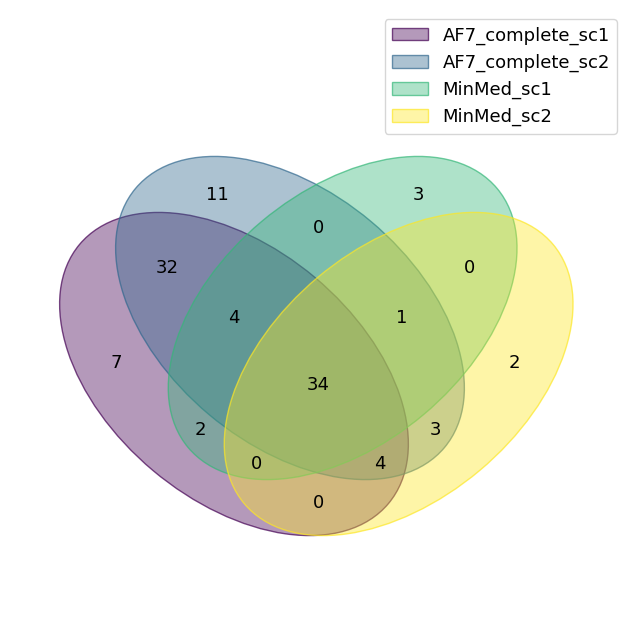

In [233]:
venn(helper_d)

### 9.3 Combine and save the AF7-completed medium

In [28]:
# Merge af_c1 and af_c2: if a reaction appears in both, keep the higher flux bound.
combined_afmedium = af_c1
for ex_r, flux in af_c2.items():
    if ex_r not in combined_afmedium.keys():
        combined_afmedium[ex_r] = flux
    if ex_r in combined_afmedium.keys():
        if combined_afmedium[ex_r] < flux:
            combined_afmedium[ex_r] = flux

In [29]:
len(combined_afmedium)

52

In [80]:
a = set(AF7_s.keys()).intersection(set(HvSC1_af7_1.keys()))

In [81]:
len(a)

43

In [46]:
added_combined = set(AF7_s.index) - a 

In [47]:
added_combined

{'EX_2hg_m',
 'EX_2kgnd_m',
 'EX_5htrp_m',
 'EX_campst_m',
 'EX_gltar_m',
 'EX_glycrt_m',
 'EX_male_m',
 'EX_mi_oind_m',
 'EX_mrgst_m',
 'EX_oph_m',
 'EX_raff_m',
 'EX_ribn_m',
 'EX_sitost_m',
 'EX_stigmast_m',
 'EX_threone_m'}

In [39]:
save_media(combined_afmedium.to_dict(), "combined_af7", media_dir)

,0
EX_4abut_m,10.000000
EX_acmana_m,0.000035
EX_acon_C_m,0.100000
EX_ala__L_m,10.000000
EX_asn__L_m,0.000268
EX_asp__L_m,10.000000
EX_ca2_m,1000.000000
EX_cit_m,10.000000
EX_cl_m,1000.000000
EX_cobalt2_m,1000.000000


### 9.4 Metabolite-class breakdown of the combined AF7 medium

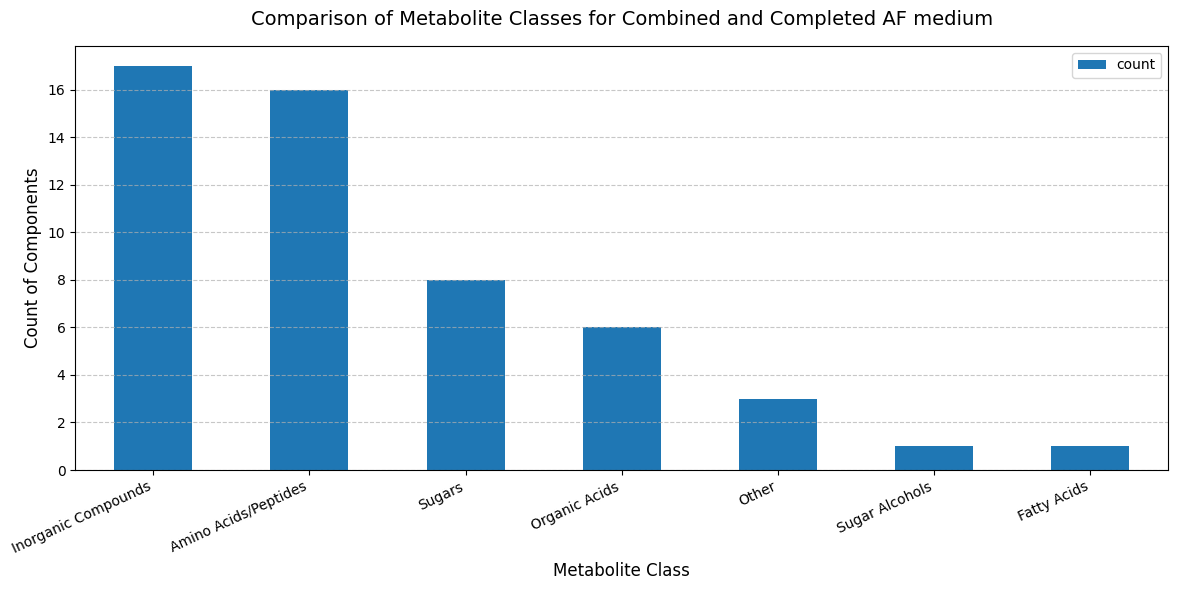

In [60]:
### analyze combined medium 
met_class_df = pd.read_csv(met_class)
met_class_dict = dict(zip(met_class_df["Reaction"], met_class_df["Category"]))

as_d, c_d = assign_metaboliteclass_medium(combined_afmedium, met_class_dict)
df_counts = pd.Series(c_d).to_frame(name="count")

df_counts = df_counts.drop([0, 1], errors='ignore')
df_counts = pd.Series(c_d).to_frame(name = "count")
df_counts = df_counts.sort_values(by="count", ascending=False)
ax = df_counts.plot(kind='bar', figsize=(12, 6))

plt.title("Comparison of Metabolite Classes for Combined and Completed AF medium", fontsize=14, pad=15)
plt.xlabel("Metabolite Class", fontsize=12)
plt.ylabel("Count of Components", fontsize=12)
plt.xticks(rotation=25, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.legend(title="Media Profiles")

plt.tight_layout()
plt.show()

### 9.5 Uptake and Interaction Analysis on Completed AF7 Medium

In [242]:
grow_sc1 = grow(manifest_sc1, model_dir, af_complete, tradeoff = 0.5)

Output()

In [243]:
grow_sc2 = grow(manifest_sc2, model_dir, af_complete, tradeoff = 0.5)

Output()

### 10.1 Which exchanges are actually taken up?

In [18]:
uptake_sc1 = grow_sc1.exchanges[grow_sc1.exchanges["direction"] == "import"]
uptake_sc2 = grow_sc2.exchanges[grow_sc2.exchanges["direction"] == "import"]

In [19]:
# 2. SEPARATE ENVIRONMENT VS INTERNAL FLUXES
env_uptake_sc1 = uptake_sc1[uptake_sc1["taxon"] == "medium"]
env_uptake_sc2 = uptake_sc2[uptake_sc2["taxon"] == "medium"]
# Cross-feeding comes from individual strains importing something NOT provided by the medium
strain_uptake_sc1 = uptake_sc1[uptake_sc1["taxon"] != "medium"]
strain_uptake_sc2 = uptake_sc2[uptake_sc2["taxon"] != "medium"]

def clean_id(met_id):
    # First, strip the EX_ prefix if it exists
    if met_id.startswith("EX_"):
        met_id = met_id[3:]
        
    # Next, handle the trailing compartment/medium tags
    if met_id.endswith("_m"): return met_id[:-2]
    if met_id.endswith("_e"): return met_id[:-2]
    if met_id.endswith("_medium"): return met_id[:-7]
    return met_id

# Clean your index and find unique microbial uptakes
clean_medium_items = set(clean_id(m) for m in af_complete.index)

unique_strain_sc1_mets = strain_uptake_sc1["metabolite"].drop_duplicates()
unique_strain_sc2_mets = strain_uptake_sc2["metabolite"].drop_duplicates()

uptakes_sc1 = []
crossfeed_sc1 = []

uptakes_sc2 = []
crossfeed_sc2 = []

for raw_met in unique_strain_sc1_mets:
    cleaned_met = clean_id(raw_met)
    
    # Check against the cleaned index reference
    if cleaned_met in clean_medium_items:
        uptakes_sc1.append(cleaned_met)
    else:
        crossfeed_sc1.append(cleaned_met)

print(f"True Medium Uptakes: {len(uptakes_sc1)}")
print(f"Cross-fed Metabolites: {len(crossfeed_sc1)}")

for raw_met in unique_strain_sc2_mets:
    cleaned_met = clean_id(raw_met)
    
    # Check against the cleaned index reference
    if cleaned_met in clean_medium_items:
        uptakes_sc2.append(cleaned_met)
    else:
        crossfeed_sc2.append(cleaned_met)

print(f"True Medium Uptakes: {len(uptakes_sc2)}")
print(f"Cross-fed Metabolites: {len(crossfeed_sc2)}")

True Medium Uptakes: 79
Cross-fed Metabolites: 36
True Medium Uptakes: 91
Cross-fed Metabolites: 58


In [25]:
grow_sc1.growth_rates.reset_index(drop=True, inplace=True)
grow_sc1.exchanges.reset_index(drop=True, inplace=True)
if hasattr(grow_sc1, "annotations") and grow_sc2.annotations is not None:
    grow_sc1.annotations.reset_index(drop=True, inplace=True)
mes_sc1 = MES(grow_sc1)

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/scores.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mes = fluxes.groupby(["metabolite", "sample_id"]).apply(_mes).reset_index()


In [21]:
mes_sc2 = MES(grow_sc2)

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/scores.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mes = fluxes.groupby(["metabolite", "sample_id"]).apply(_mes).reset_index()


In [26]:
cross_fed_mets_sc1 = mes_sc1[mes_sc1["MES"] !=0].sort_values(by = "MES", ascending = False)

In [23]:
cross_fed_mets_sc2.head(10)

,metabolite,sample_id,MES,name,molecular_weight,C_number,N_number,sbo,reactome,kegg.compound,chebi,hmdb,lipidmaps,biocyc,metanetx.chemical,inchikey,seed.compound,kegg.drug,kegg.glycan,reaction
77,glc__D_e,HvSC2,12.307692,D-Glucose,180.155880,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EX_glc__D_e
72,fru_e,HvSC2,12.000000,D-Fructose,180.155880,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EX_fru_e
65,fad_e,HvSC2,11.304348,Flavin adenine dinucleotide oxidized,783.533862,27,9,SBO:0000247,"['R-ALL-113596', 'R-ALL-113597', 'R-ALL-29386']",C00016,"['CHEBI:13315', 'CHEBI:16238', 'CHEBI:21125', ...",HMDB01248,NaN,META:FAD,MNXM33,IMGVNJNCCGXBHD-UYBVJOGSSA-K,cpd00015,D00005,NaN,EX_fad_e
80,glu__L_e,HvSC2,11.250000,L-Glutamate,146.121320,5,1,SBO:0000247,"['R-ALL-113552', 'R-ALL-210382', 'R-ALL-29404'...","['C00025', 'C00302']","['CHEBI:13107', 'CHEBI:14321', 'CHEBI:16015', ...","['HMDB00148', 'HMDB60475']",NaN,"['META:GLT', 'META:Glutamates']",MNXM89557,WHUUTDBJXJRKMK-VKHMYHEASA-M,"['cpd00023', 'cpd19002', 'cpd27177']","['D00007', 'D04341']",NaN,EX_glu__L_e
98,h2s_e,HvSC2,10.666667,Hydrogen sulfide,34.080880,0,0,SBO:0000247,"['R-ALL-1614532', 'R-ALL-1655881', 'R-ALL-1663...",C00283,"['CHEBI:13356', 'CHEBI:14414', 'CHEBI:15138', ...","['HMDB00598', 'HMDB03276']",NaN,"['META:CPD-7046', 'META:CPD-846', 'META:HS']",MNXM89582,RWSOTUBLDIXVET-UHFFFAOYSA-M,"['cpd00239', 'cpd24697']",NaN,NaN,EX_h2s_e
139,pi_e,HvSC2,10.636364,Phosphate,95.979301,0,0,SBO:0000247,"['R-ALL-109277', 'R-ALL-113548', 'R-ALL-113550...",C00009,"['CHEBI:14791', 'CHEBI:18367', 'CHEBI:26020', ...","['HMDB00973', 'HMDB01429', 'HMDB02105', 'HMDB0...",NaN,"['META:CPD-16459', 'META:PHOSPHATE-GROUP', 'ME...",MNXM9,NBIIXXVUZAFLBC-UHFFFAOYSA-L,"['cpd00009', 'cpd27787']",D05467,NaN,EX_pi_e
97,h2o_e,HvSC2,10.230769,H2O H2O,18.015280,0,0,SBO:0000247,"['R-ALL-109276', 'R-ALL-113518', 'R-ALL-113519...","['C00001', 'C01328']","['CHEBI:10743', 'CHEBI:13352', 'CHEBI:13365', ...","['HMDB01039', 'HMDB02111']",NaN,"['META:CPD-15815', 'META:HYDROXYL-GROUP', 'MET...",MNXM2,XLYOFNOQVPJJNP-UHFFFAOYSA-N,"['cpd00001', 'cpd15275', 'cpd27222']","['D00001', 'D06322']",NaN,EX_h2o_e
85,gly_e,HvSC2,10.230769,Glycine,75.066600,2,1,SBO:0000247,"['R-ALL-113545', 'R-ALL-159549', 'R-ALL-193446...",C00037,"['CHEBI:10792', 'CHEBI:14344', 'CHEBI:15428', ...",HMDB00123,NaN,META:GLY,MNXM29,DHMQDGOQFOQNFH-UHFFFAOYSA-N,cpd00033,D00011,NaN,EX_gly_e
99,h_e,HvSC2,9.230769,H+,1.007940,0,0,SBO:0000247,"['R-ALL-1132304', 'R-ALL-113529', 'R-ALL-14700...",C00080,"['CHEBI:10744', 'CHEBI:13357', 'CHEBI:15378', ...",HMDB59597,NaN,META:PROTON,MNXM1,GPRLSGONYQIRFK-UHFFFAOYSA-N,cpd00067,NaN,NaN,EX_h_e
125,nh4_e,HvSC2,8.076923,Ammonium,18.038460,0,1,SBO:0000247,"['R-ALL-1132163', 'R-ALL-113561', 'R-ALL-14091...","['C00014', 'C01342']","['CHEBI:13405', 'CHEBI:13406', 'CHEBI:13407', ...","['HMDB00051', 'HMDB41827']",NaN,"['META:AMMONIA', 'META:AMMONIUM']",MNXM15,QGZKDVFQNNGYKY-UHFFFAOYSA-O,"['cpd00013', 'cpd19013']","['D02915', 'D02916']",NaN,EX_nh4_e


In [22]:
cross_fed_mets_sc2 = mes_sc2[mes_sc2["MES"]!=0].sort_values(by = "MES", ascending = False)

In [27]:
len(cross_fed_mets_sc1)

54

In [215]:
inter_sc1 = interactions(grow_sc1, taxa = None)

Output()

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

...

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:77: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: sample_interactions(df, df.name, taxon))

In [ ]:
inter_sc2.to_csv(os.path.join(community_dir, "simulations/interactions_sc2_tsb_com_complete.csv"))

In [218]:
inter_sc2 = interactions(grow_sc2, taxa = None)

Output()

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

...

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:62: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: _metabolite_interaction(df, taxon, p))

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/focal.py:77: FutureWarning: 
DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 
pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 
groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: sample_interactions(df, df.name, taxon))

In [216]:
summary_inter_sc1 = summarize_interactions(inter_sc1)

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/summary.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ints.groupby("class").apply(
/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/summary.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ints.groupby("class").apply(
/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/

In [220]:
summary_inter_sc2

,sample_id,focal,partner,class,flux,mass_flux,C_flux,N_flux,n_ints
0,HvSC2,m_1080,m_1101,co-consumed,0.004044,9.289696e-05,0.002440,0.000585,32
1,HvSC2,m_1080,m_1101,provided,0.001461,2.620769e-04,0.008748,0.000017,2
2,HvSC2,m_1080,m_1101,received,0.003919,4.224101e-04,0.013001,0.000000,3
3,HvSC2,m_1080,m_1114,co-consumed,0.019193,2.516315e-03,0.089336,0.027580,39
4,HvSC2,m_1080,m_1114,provided,0.301057,5.419097e-02,1.805631,0.000710,2
...,...,...,...,...,...,...,...,...,...
1773,HvSC2,m_997,m_947,co-consumed,0.600276,1.071051e-01,3.559533,0.001434,30
1774,HvSC2,m_997,m_947,provided,0.016359,2.947143e-04,0.000000,0.000000,1
1775,HvSC2,m_997,m_947,received,0.000654,6.592120e-07,0.000000,0.000000,1
1776,HvSC2,m_997,m_978,co-consumed,0.309803,5.454913e-02,1.810053,0.002457,35


In [219]:
summary_inter_sc2 = summarize_interactions(inter_sc2)

/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/summary.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ints.groupby("class").apply(
/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/interaction/summary.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return ints.groupby("class").apply(
/home/emma/miniconda3/envs/micom/lib/python3.10/site-packages/micom/